In [1]:
# =============================================================================
# CR39 ANALYSIS V2
# IISER Pune – Nuclear Physics Group
#
# Experiment:
#     13C(d,p)14C
#
# Detector:
#     CR-39 Nuclear Track Detector
#
# Version:
#     2.0
#
# Improvements expected to be done:
# ------------------
# • Incident-angle calculation
# • Position-dependent eccentricity correction
# • Diameter correction
# • Updated background subtraction
# • Publication-quality plots
# • Automatic statistics
#
# =============================================================================

# =============================================================================
# Standard Library
# =============================================================================

import os
import struct
import warnings

warnings.filterwarnings("ignore")

# =============================================================================
# Numerical Libraries
# =============================================================================

import numpy as np
import pandas as pd

# =============================================================================
# Plotting
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator

# =============================================================================
# Progress Bar
# =============================================================================

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# =============================================================================
# Colab Upload
# =============================================================================

# from google.colab import files

print("\nUpload ONE CPSA file.\n")

# uploaded = files.upload()

if False:
    raise RuntimeError(
        "Please upload exactly ONE .cpsa file."
    )

CPSA_FILE = "../CR-39_data/A20260413_13CD_125-50umTaFilter_W75_5hr_40x_backside_s0.cpsa"

print("\nLoaded file:")
print(CPSA_FILE)


Upload ONE CPSA file.


Loaded file:
../CR-39_data/A20260413_13CD_125-50umTaFilter_W75_5hr_40x_backside_s0.cpsa


In [2]:
# =============================================================================
# Publication Plot Style
# =============================================================================

plt.rcParams.update({

    "figure.dpi":200,

    "figure.figsize":(7,5),

    "font.size":13,

    "axes.labelsize":14,

    "axes.titlesize":15,

    "xtick.labelsize":12,

    "ytick.labelsize":12,

    "legend.fontsize":11,

    "xtick.direction":"in",

    "ytick.direction":"in",

    "xtick.top":True,

    "ytick.right":True,

    "axes.linewidth":1.2,

    "lines.linewidth":2,

    "savefig.bbox":"tight"

})

print("Plot style loaded.")

Plot style loaded.


In [3]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# ----------------------------
# Detector Geometry
# ----------------------------

TARGET_TO_DETECTOR_CM = 6.00

CR39_RADIUS_CM = 2.50

# ----------------------------
# Quality Cuts
# ----------------------------

D_MIN = 2.0
D_MAX = 13.0

ECC_MIN = 0
ECC_MAX = 15

CONTRAST_MIN = 0
CONTRAST_MAX = 20

# ----------------------------
# Spatial Limits
# ----------------------------

X_MIN = -2.5
X_MAX = 2.5

Y_MIN = -2.5
Y_MAX = 2.5

# ----------------------------
# Signal Region
# ----------------------------

SIG_R_MAX = 1.50


# ----------------------------
# Background Region
# ----------------------------

BG_R_MIN = 1.50
BG_R_MAX =  2.00


# ----------------------------
# Histogram Bins
# ----------------------------

BINS_D = 100
BINS_C = 50
BINS_E = 50
BINS_R = 100
BINS_XY = 100

# ----------------------------
# Output Directory
# ----------------------------

OUTPUT_DIR = "plots"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("Configuration loaded.")

Configuration loaded.


In [4]:
# =============================================================================
# Utility Functions
# =============================================================================

def circle_area(radius):

    return np.pi * radius**2


def print_header(title):

    print("\n")
    print("="*80)
    print(title)
    print("="*80)


def savefig(name):

    plt.savefig(

        os.path.join(

            OUTPUT_DIR,

            name

        ),

        dpi=400

    )


print("Utility functions loaded.")

Utility functions loaded.


In [5]:
class ScanData:
    """
    Fast reader for CR-39 CPSA binary scan files.

    Parameters
    ----------
    path       : str   – Path to the .cpsa file.
    d_bounds   : (min, max) – Diameter filter in µm.
    e_bounds   : (min, max) – Eccentricity filter (raw int8).
    c_bounds   : (min, max) – Normal contrast filter (raw int8).
    a_bounds   : (min, max) – Average contrast filter (raw int8).
    x_bounds   : (min, max) – Spatial x filter in cm.
    y_bounds   : (min, max) – Spatial y filter in cm.

    Attributes
    ----------
    header  : dict       – Scan metadata (pixel size, frame dimensions, …)
    frames  : DataFrame  – Per-frame info (position, num_tracks, focus, …)
    tracks  : DataFrame  – Track data (d, x, y, e, c, a, frame_number)
    trailer : str        – ASCII trailer appended by the scanner software.
    """

    def __init__(self, path,
                 d_bounds=(0, np.inf),
                 e_bounds=(0, np.inf),
                 c_bounds=(0, np.inf),
                 a_bounds=(0, np.inf),
                 x_bounds=(-np.inf, np.inf),
                 y_bounds=(-np.inf, np.inf)):
        self.header  = {}
        self.frames  = None
        self.tracks  = None
        self.trailer = ''

        with open(path, 'rb') as f:
            self._parse_header(f)
            self._parse_data(f, d_bounds, e_bounds, c_bounds,
                             a_bounds, x_bounds, y_bounds)
            self._parse_trailer(f)

    # ── Helper: read a little-endian int32 ────────────────────────────────────
    @staticmethod
    def _ri(f):
        return struct.unpack('<i', f.read(4))[0]

    @staticmethod
    def _rf(f):
        return struct.unpack('<f', f.read(4))[0]

    # ── Header (48 bytes) ─────────────────────────────────────────────────────
    def _parse_header(self, f):
        ri, rf = self._ri, self._rf
        ps = 1e-4 * rf(f)  # pixel size in cm — read after version/dim fields below

        # Re-read in correct order (version_number is field 0)
        f.seek(0)  # rewind
        h = {
            'version_number':     ri(f),
            'num_x_frames':       ri(f),
            'num_y_frames':       ri(f),
            'num_bins':           ri(f),
            'pixel_size':   1e-4 * rf(f),   # cm per pixel
            'pixels_per_bin':     rf(f),
            'border_limit':       ri(f),
            'contrast_limit':     ri(f),
            'eccentricity_limit': ri(f),
            'M':                  ri(f),
            'frame_width':        ri(f),    # in pixels — converted below
            'frame_height':       ri(f),    # in pixels — converted below
        }
        ps = h['pixel_size']
        h['frame_width']  *= ps   # → cm
        h['frame_height'] *= ps   # → cm
        self.header = h

    # ── Frame + track data ────────────────────────────────────────────────────
    def _parse_data(self, f, d_bounds, e_bounds, c_bounds,
                   a_bounds, x_bounds, y_bounds):
        ps = self.header['pixel_size']
        fw = self.header['frame_width']
        fh = self.header['frame_height']
        num_frames = self.header['num_x_frames'] * self.header['num_y_frames']

        frame_rows = []   # collect frame metadata
        track_chunks = [] # collect filtered track arrays (one ndarray per frame)

        for _ in tqdm(range(num_frames), desc='Reading frames', unit='fr'):
            # ── Frame header (28 bytes) ────────────────────────────────────
            number      = struct.unpack('<i', f.read(4))[0]
            x_pos       = 1e-5 * struct.unpack('<i', f.read(4))[0]  # cm
            y_pos       = 1e-5 * struct.unpack('<i', f.read(4))[0]  # cm
            num_tracks  = struct.unpack('<i', f.read(4))[0]
            f.read(12)   # skip 3 unused int32 fields
            focus       = 1e-2 * struct.unpack('<i', f.read(4))[0]  # µm
            xi          = struct.unpack('<i', f.read(4))[0]          # x index
            yi          = struct.unpack('<i', f.read(4))[0]          # y index

            frame_rows.append((number, x_pos, y_pos, num_tracks,
                               focus, xi, yi))

            if num_tracks == 0:
                continue

            # ── Bulk-read all six track arrays at once ─────────────────────
            # Layout in file: d[n], e[n], c[n], a[n], x[n], y[n]
            d_raw = np.frombuffer(f.read(2 * num_tracks), dtype='<i2')  # int16 → µm after scale
            e_raw = np.frombuffer(f.read(num_tracks),     dtype='<i1')  # int8  eccentricity
            c_raw = np.frombuffer(f.read(num_tracks),     dtype='<i1')  # int8  normal contrast
            a_raw = np.frombuffer(f.read(num_tracks),     dtype='<i1')  # int8  average contrast
            x_raw = np.frombuffer(f.read(2 * num_tracks), dtype='<i2')  # int16 pixel position
            y_raw = np.frombuffer(f.read(2 * num_tracks), dtype='<i2')  # int16 pixel position

            # ── Unit conversion (vectorised) ───────────────────────────────
            d_um = 100.0 * d_raw * ps         # diameter in µm
            x_cm = x_pos - 0.5*fw + x_raw*ps  # absolute x in cm
            y_cm = y_pos - 0.5*fh + y_raw*ps  # absolute y in cm

            # ── Vectorised quality + spatial filter ────────────────────────
            mask = (
                (d_um  >= d_bounds[0]) & (d_um  <= d_bounds[1]) &
                (e_raw >= e_bounds[0]) & (e_raw <= e_bounds[1]) &
                (c_raw >= c_bounds[0]) & (c_raw <= c_bounds[1]) &
                (a_raw >= a_bounds[0]) & (a_raw <= a_bounds[1]) &
                (x_cm  >= x_bounds[0]) & (x_cm  <= x_bounds[1]) &
                (y_cm  >= y_bounds[0]) & (y_cm  <= y_bounds[1])
            )

            n_pass = mask.sum()
            if n_pass == 0:
                continue

            # Pack selected tracks into a (n_pass × 7) float64 array
            chunk = np.empty((n_pass, 7), dtype=np.float64)
            chunk[:, 0] = number          # frame_number (stored as float, cast later)
            chunk[:, 1] = d_um[mask]      # d  [µm]
            chunk[:, 2] = x_cm[mask]      # x  [cm]
            chunk[:, 3] = y_cm[mask]      # y  [cm]
            chunk[:, 4] = e_raw[mask]     # e  (eccentricity)
            chunk[:, 5] = c_raw[mask]     # c  (normal contrast)
            chunk[:, 6] = a_raw[mask]     # a  (average contrast)
            track_chunks.append(chunk)

        # ── Build DataFrames once at the end (avoids costly pd.concat in loop) ─
        self.frames = pd.DataFrame(frame_rows, columns=[
            'number', 'x_position', 'y_position', 'num_tracks',
            'focus', 'x_position_index', 'y_position_index'
        ])

        if track_chunks:
            arr = np.vstack(track_chunks)
            self.tracks = pd.DataFrame(arr, columns=[
                'frame_number', 'd', 'x', 'y', 'e', 'c', 'a'
            ])
            # Restore compact dtypes to save memory
            self.tracks['frame_number'] = self.tracks['frame_number'].astype(np.int32)
            self.tracks[['e', 'c', 'a']] = self.tracks[['e', 'c', 'a']].astype(np.int8)
            self.tracks[['d', 'x', 'y']] = self.tracks[['d', 'x', 'y']].astype(np.float32)
        else:
            self.tracks = pd.DataFrame(
                columns=['frame_number', 'd', 'x', 'y', 'e', 'c', 'a'])

    # ── Trailer (ASCII metadata appended by scanner) ──────────────────────────
    def _parse_trailer(self, f):
        f.read(4)  # skip 4-byte separator
        self.trailer = f.read().decode('latin-1')

    def __repr__(self):
        h = self.header
        return (
            f'ScanData  {h["num_x_frames"]}×{h["num_y_frames"]} frames  '
            f'pixel={h["pixel_size"]*1e4:.4f} µm  '
            f'tracks={len(self.tracks):,}'
        )


print('ScanData class defined')

ScanData class defined


In [6]:
# =============================================================================
# LOAD CPSA DATA
# =============================================================================

print_header("LOADING CPSA DATA")

# ------------------------------------------------------------------
# IMPORTANT:
# We intentionally keep loose morphology cuts here.
# Dynamic eccentricity / contrast cuts are applied later after
# incidence-angle calculation.
# ------------------------------------------------------------------

data = ScanData(
    CPSA_FILE,

    d_bounds=(D_MIN, D_MAX),

    e_bounds=(0,127),
    c_bounds=(0,127),

    x_bounds=(X_MIN,X_MAX),
    y_bounds=(Y_MIN,Y_MAX)
)

tracks = data.tracks.copy()
frames = data.frames.copy()
header = data.header

print(data)

print(f"\nTracks : {len(tracks):,}")
print(f"Frames : {len(frames):,}")

display(tracks.head())



LOADING CPSA DATA


Reading frames:   0%|          | 0/15264 [00:00<?, ?fr/s]

ScanData  106×144 frames  pixel=0.3280 µm  tracks=326,046

Tracks : 326,046
Frames : 15,264


,frame_number,d,x,y,e,c,a
0,151,7.49152,0.354526,2.301189,0,36,53
1,151,2.27960,0.343834,2.301550,3,74,79
2,151,6.42880,0.358987,2.303748,4,25,46
3,151,2.25008,0.367810,2.304436,5,17,51
4,151,5.54976,0.359479,2.305912,4,11,35


In [7]:
# =============================================================================
# DETECTOR GEOMETRY
# =============================================================================

tracks["r_cm"] = np.sqrt(
    tracks.x**2 +
    tracks.y**2
)

tracks["theta_inc_rad"] = np.arctan(
    tracks.r_cm /
    TARGET_TO_DETECTOR_CM
)

tracks["theta_inc_deg"] = np.degrees(
    tracks.theta_inc_rad
)

tracks["cos_theta"] = np.cos(
    tracks.theta_inc_rad
)

tracks["sin_theta"] = np.sin(
    tracks.theta_inc_rad
)

print()

print("Geometry Calculated")

print(f"Maximum angle : {tracks.theta_inc_deg.max():.2f} deg")

print(f"Average angle : {tracks.theta_inc_deg.mean():.2f} deg")


Geometry Calculated
Maximum angle : 21.58 deg
Average angle : 14.40 deg


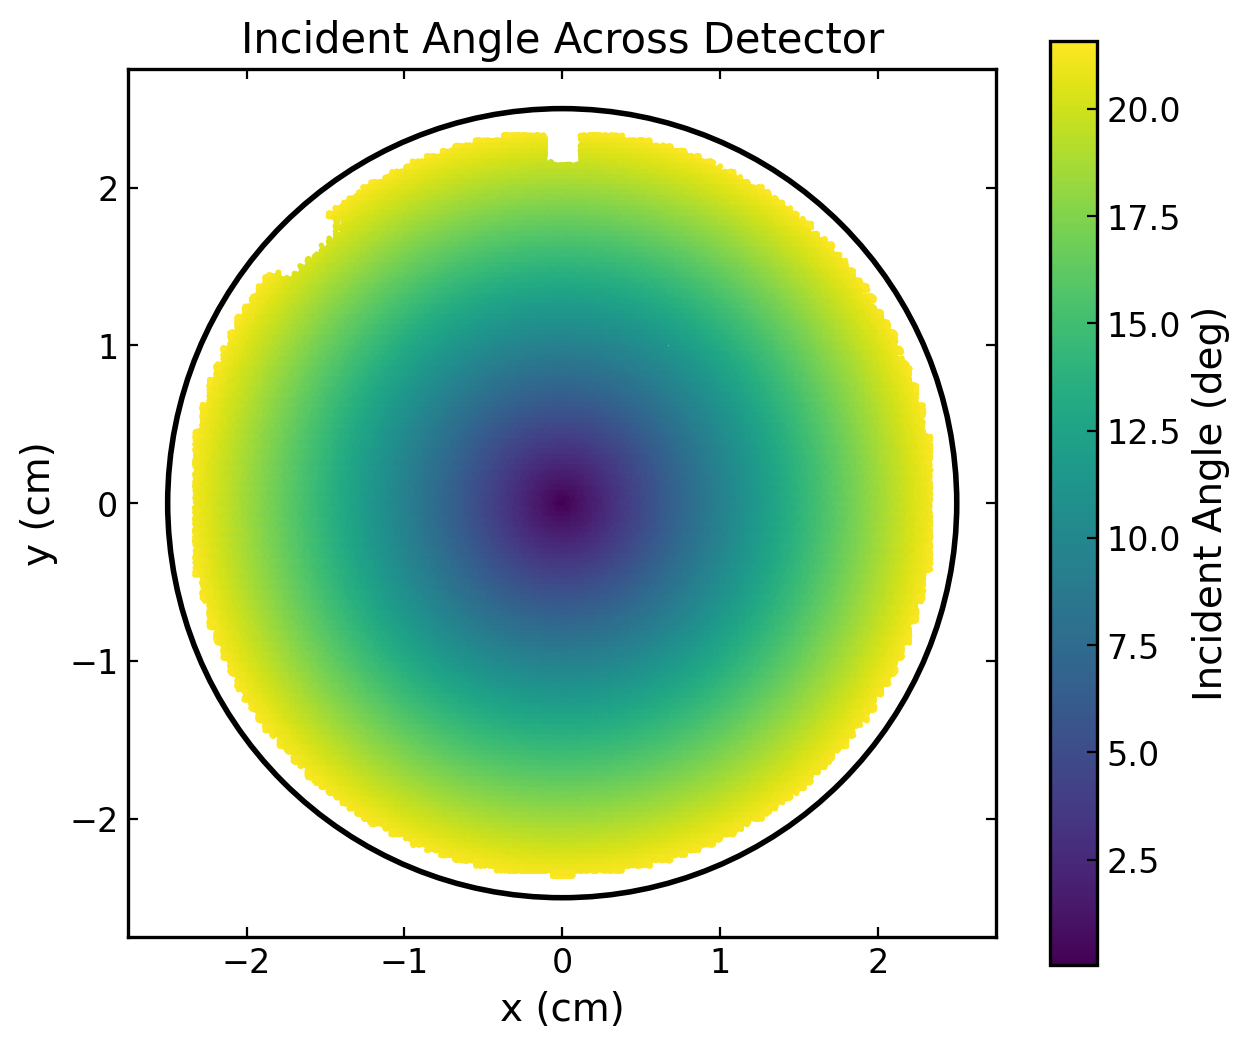

In [8]:
# =============================================================================
# INCIDENT ANGLE MAP
# =============================================================================

fig,ax=plt.subplots(figsize=(7,6))

sc=ax.scatter(

    tracks.x,
    tracks.y,

    c=tracks.theta_inc_deg,

    s=1,

    cmap="viridis"

)

circle=plt.Circle(

    (0,0),

    CR39_RADIUS_CM,

    fill=False,

    color="black",

    lw=2

)

ax.add_patch(circle)

ax.set_aspect("equal")

ax.set_xlabel("x (cm)")

ax.set_ylabel("y (cm)")

ax.set_title("Incident Angle Across Detector")

cb=plt.colorbar(sc)

cb.set_label("Incident Angle (deg)")

savefig("incident_angle_map.png")

plt.show()

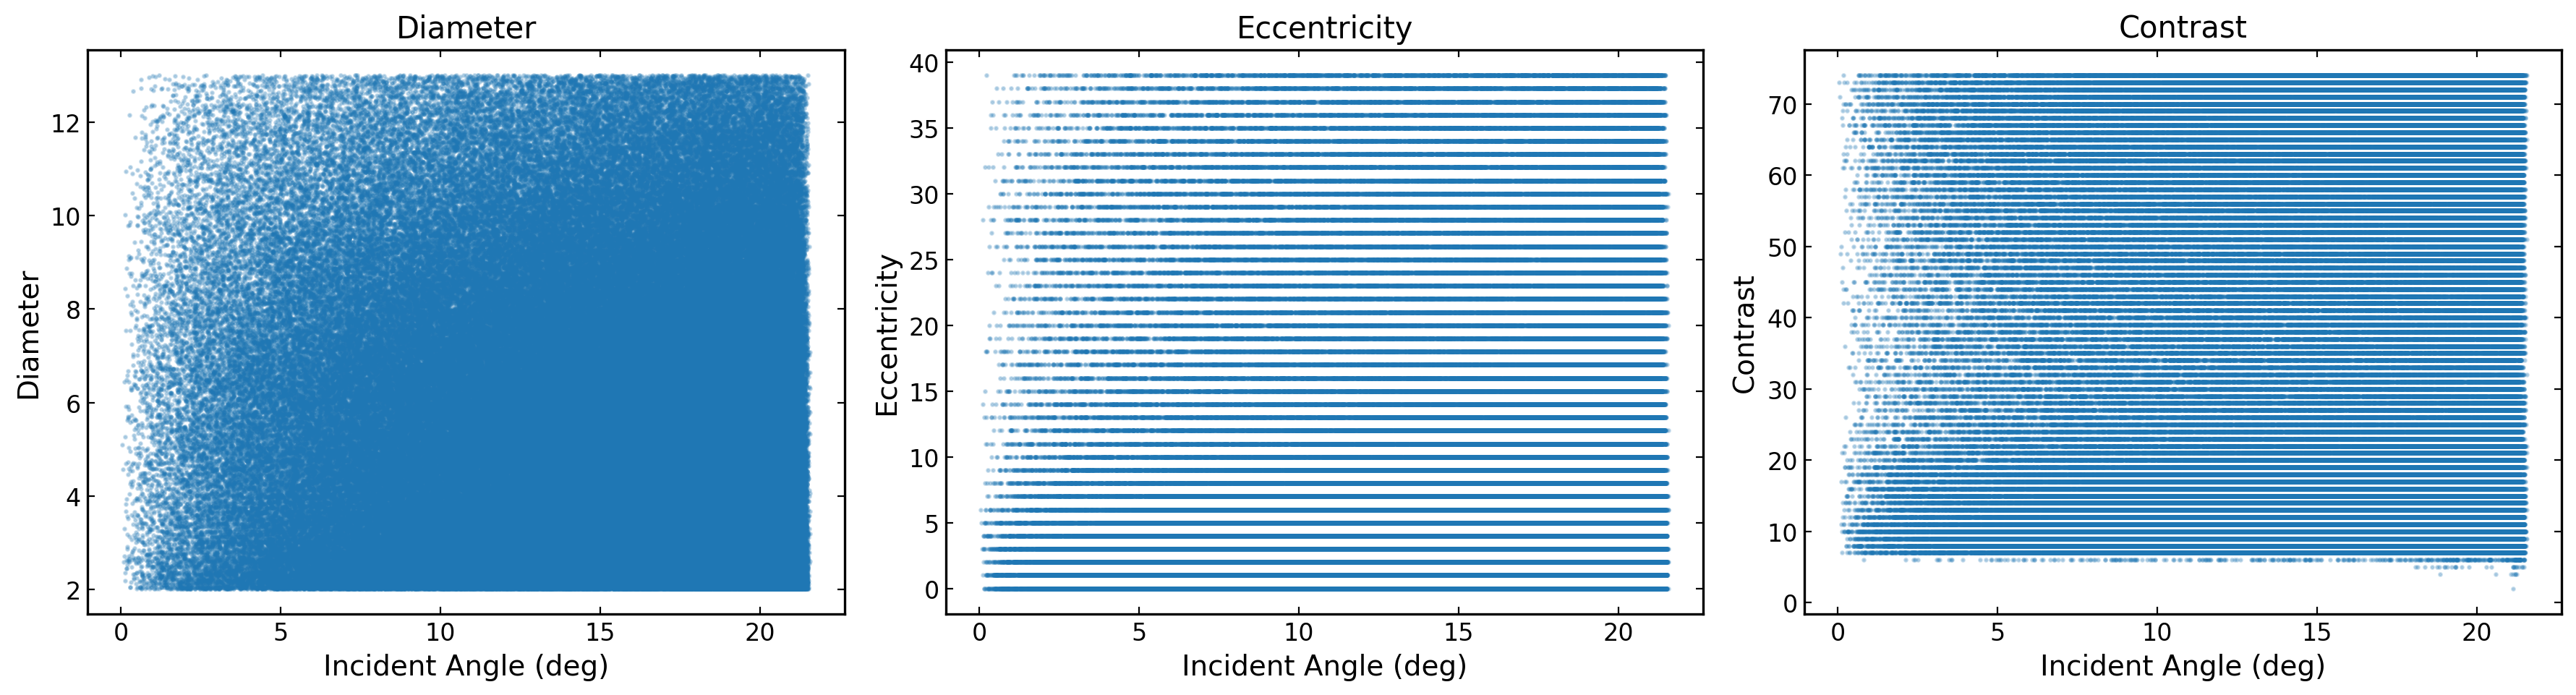

In [9]:
# =============================================================================
# MORPHOLOGY DIAGNOSTICS
# =============================================================================

fig,axs=plt.subplots(
    1,
    3,
    figsize=(18,5)
)

axs[0].scatter(

    tracks.theta_inc_deg,

    tracks.d,

    s=2,

    alpha=.25

)

axs[0].set_xlabel("Incident Angle (deg)")
axs[0].set_ylabel("Diameter")

axs[0].set_title("Diameter")

# ---------------------------------------

axs[1].scatter(

    tracks.theta_inc_deg,

    tracks.e,

    s=2,

    alpha=.25

)

axs[1].set_xlabel("Incident Angle (deg)")
axs[1].set_ylabel("Eccentricity")

axs[1].set_title("Eccentricity")

# ---------------------------------------

axs[2].scatter(

    tracks.theta_inc_deg,

    tracks.c,

    s=2,

    alpha=.25

)

axs[2].set_xlabel("Incident Angle (deg)")
axs[2].set_ylabel("Contrast")

axs[2].set_title("Contrast")

plt.tight_layout()

savefig("morphology_vs_angle.png")

plt.show()

In [10]:
# =============================================================================
# BINNED MORPHOLOGY
# =============================================================================

bins=np.arange(0,31,2)

tracks["theta_bin"]=pd.cut(

    tracks.theta_inc_deg,

    bins

)

stats=(

    tracks

    .groupby("theta_bin")

    .agg(

        diameter=("d","mean"),

        diameter_std=("d","std"),

        eccentricity=("e","mean"),

        eccentricity_std=("e","std"),

        contrast=("c","mean"),

        contrast_std=("c","std"),

        N=("d","size")

    )

)

centers=np.array(

    [

        i.mid

        for i in stats.index

    ]

)

display(stats)

,diameter,diameter_std,eccentricity,eccentricity_std,contrast,contrast_std,N
theta_bin,,,,,,,
"(0, 2]",5.871835,2.874599,7.913122,9.702463,32.579308,22.920346,2774
"(2, 4]",5.934207,2.855656,8.121597,9.943177,32.404468,22.759729,8191
"(4, 6]",5.865423,2.852455,7.846182,9.906082,32.799956,22.988314,13737
"(6, 8]",5.811291,2.839218,7.941306,9.801791,33.212210,23.041107,19542
"(8, 10]",5.818205,2.818477,8.065645,9.924197,33.890235,23.407480,25181
"(10, 12]",5.868650,2.837711,8.116175,9.945372,33.408580,23.216244,30256
"(12, 14]",5.835550,2.820323,8.242023,9.997504,33.524119,23.240002,36133
"(14, 16]",5.845130,2.837651,8.336418,10.084792,33.333245,23.149403,41603
"(16, 18]",5.792386,2.838367,8.230864,9.962664,33.983286,23.149714,47985


In [11]:
# =============================================================================
# EMPIRICAL ACCEPTANCE FUNCTIONS
# =============================================================================

def eccentricity_limit(theta):

    theta=np.asarray(theta)

    return np.minimum(

        15 + 0.35*theta,

        25

    )

def contrast_limit(theta):

    theta=np.asarray(theta)

    return np.minimum(

        20 + 0.45*theta,

        35

    )

In [12]:
# =============================================================================
# APPLY DYNAMIC CUTS
# =============================================================================

tracks["pass_old"]=(
    (tracks.e<=15) &
    (tracks.c<=20)
)

tracks["pass_dynamic_e"]=(
    tracks.e<=eccentricity_limit(
        tracks.theta_inc_deg
    )
)

tracks["pass_dynamic_c"]=(
    tracks.c<=contrast_limit(
        tracks.theta_inc_deg
    )
)

tracks["pass_dynamic"]=(
    tracks.pass_dynamic_e &
    tracks.pass_dynamic_c
)

print("="*60)

print(f"Original accepted : {tracks.pass_old.sum():,}")

print(f"Dynamic accepted  : {tracks.pass_dynamic.sum():,}")

print(f"Recovered tracks  : {tracks.pass_dynamic.sum()-tracks.pass_old.sum():,}")

print("="*60)

tr=tracks.loc[
    tracks.pass_dynamic
].copy()

Original accepted : 120,469
Dynamic accepted  : 142,163
Recovered tracks  : 21,694


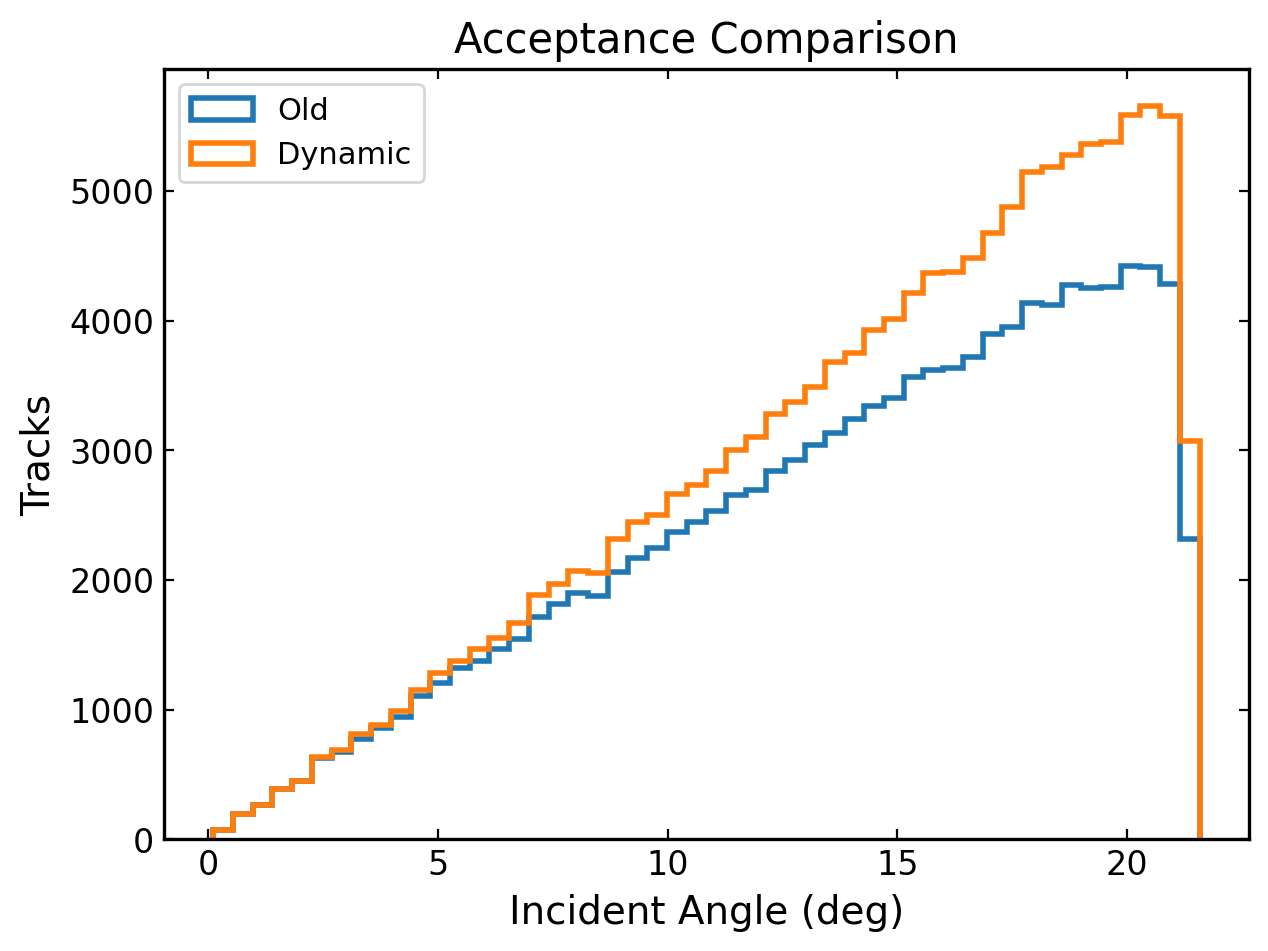

In [13]:
# =============================================================================
# ACCEPTANCE COMPARISON
# =============================================================================

fig,ax=plt.subplots(figsize=(7,5))

ax.hist(

    tracks.loc[tracks.pass_old,"theta_inc_deg"],

    bins=50,

    histtype="step",

    lw=2,

    label="Old"

)

ax.hist(

    tr.theta_inc_deg,

    bins=50,

    histtype="step",

    lw=2,

    label="Dynamic"

)

ax.legend()

ax.set_xlabel("Incident Angle (deg)")

ax.set_ylabel("Tracks")

ax.set_title("Acceptance Comparison")

savefig("acceptance_comparison.png")

plt.show()

In [14]:
# =============================================================================
# BUILD EMPIRICAL ACCEPTANCE MODEL
# =============================================================================

theta_bins = np.arange(0,31,2)

tracks["theta_bin"] = pd.cut(
    tracks.theta_inc_deg,
    theta_bins
)

acceptance = (

    tracks

    .groupby("theta_bin")

    .agg(

        e_mean=("e","mean"),
        e_std=("e","std"),

        c_mean=("c","mean"),
        c_std=("c","std"),

        d_mean=("d","mean"),
        d_std=("d","std"),

        N=("d","size")
    )

)

acceptance["theta"] = [

    i.mid

    for i in acceptance.index

]

display(acceptance)

,e_mean,e_std,c_mean,c_std,d_mean,d_std,N,theta
theta_bin,,,,,,,,
"(0, 2]",7.913122,9.702463,32.579308,22.920346,5.871835,2.874599,2774,1.0
"(2, 4]",8.121597,9.943177,32.404468,22.759729,5.934207,2.855656,8191,3.0
"(4, 6]",7.846182,9.906082,32.799956,22.988314,5.865423,2.852455,13737,5.0
"(6, 8]",7.941306,9.801791,33.212210,23.041107,5.811291,2.839218,19542,7.0
"(8, 10]",8.065645,9.924197,33.890235,23.407480,5.818205,2.818477,25181,9.0
"(10, 12]",8.116175,9.945372,33.408580,23.216244,5.868650,2.837711,30256,11.0
"(12, 14]",8.242023,9.997504,33.524119,23.240002,5.835550,2.820323,36133,13.0
"(14, 16]",8.336418,10.084792,33.333245,23.149403,5.845130,2.837651,41603,15.0
"(16, 18]",8.230864,9.962664,33.983286,23.149714,5.792386,2.838367,47985,17.0


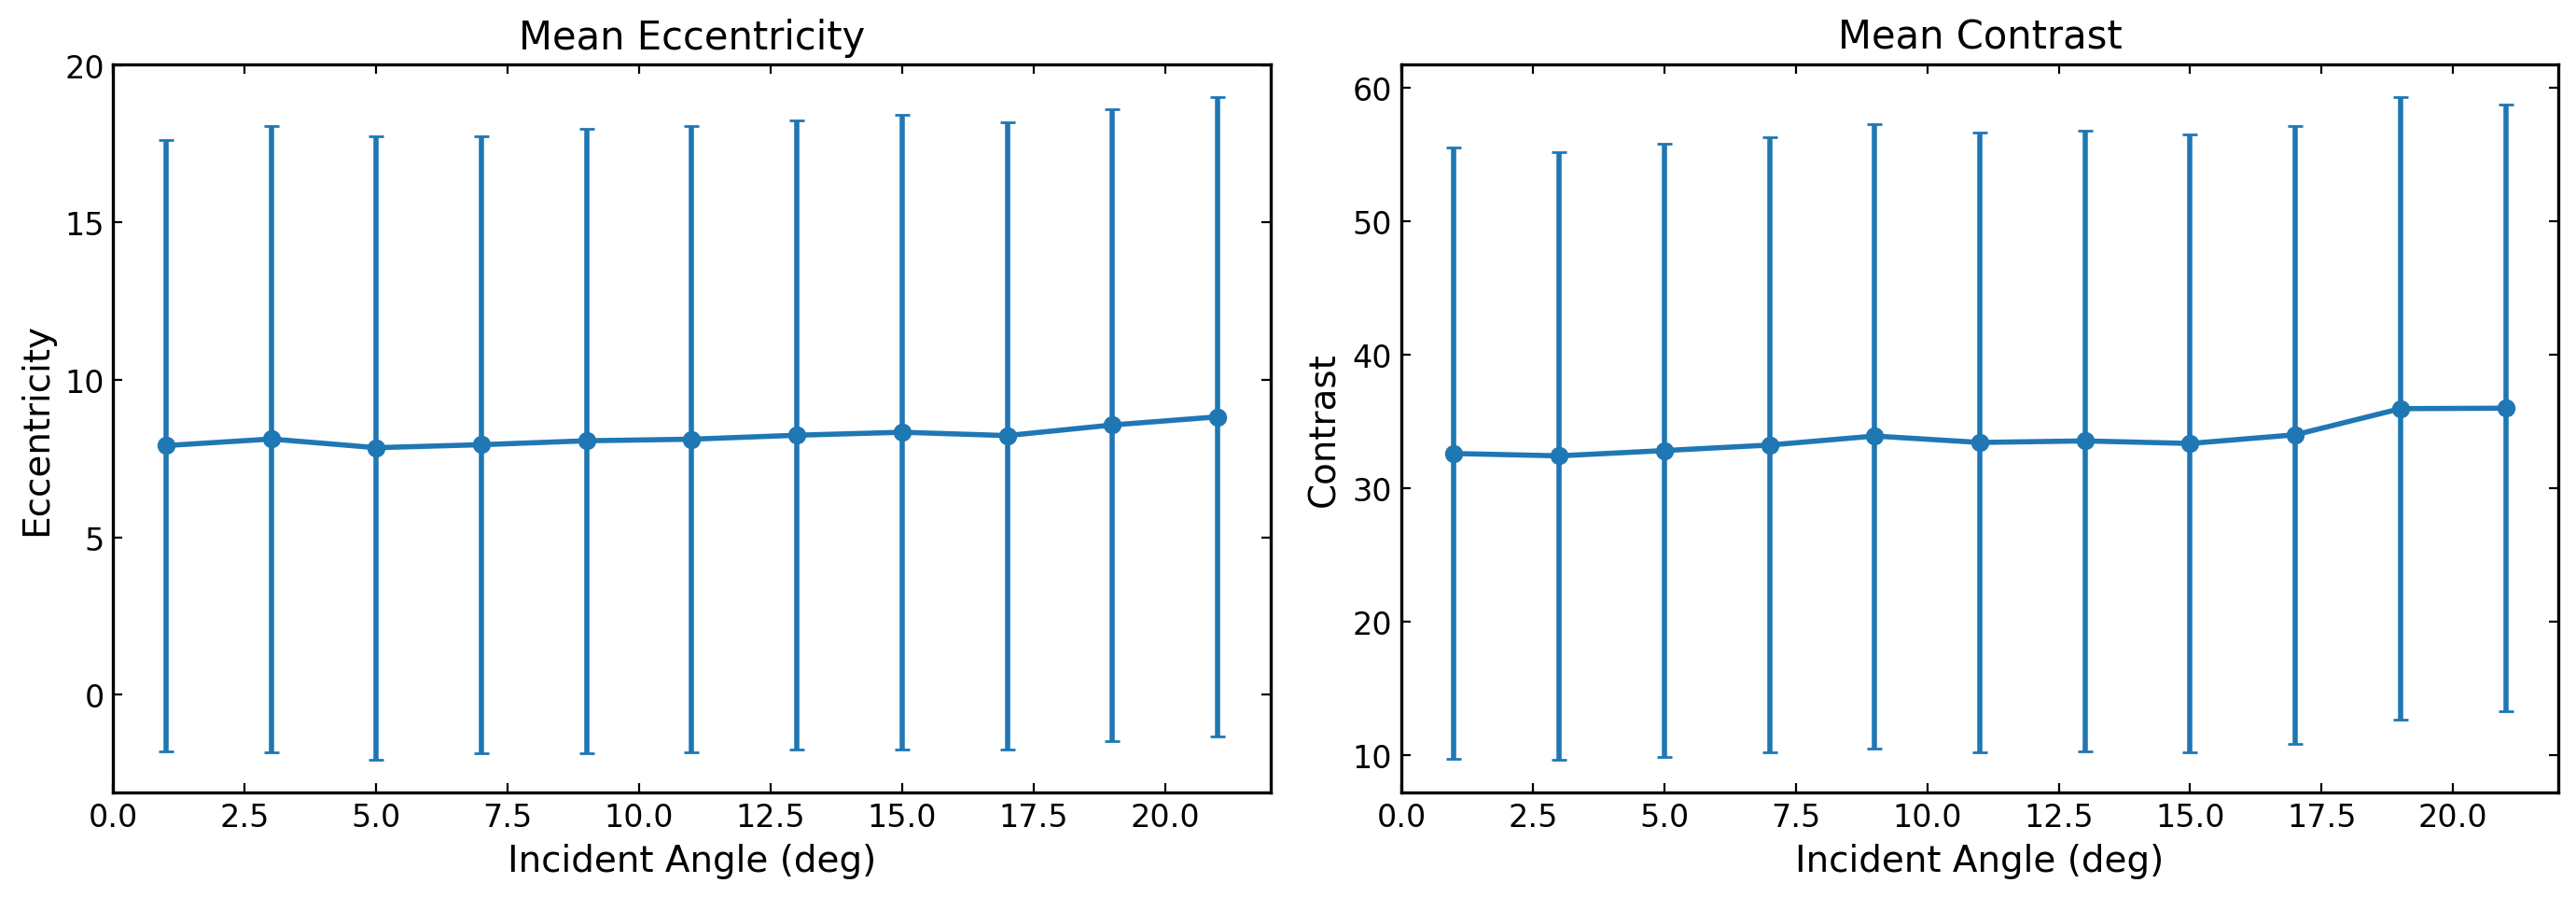

In [15]:
# =============================================================================
# ACCEPTANCE MODEL
# =============================================================================

fig,axs=plt.subplots(

    1,

    2,

    figsize=(14,5)

)

# --------------------------------------------------

axs[0].errorbar(

    acceptance.theta,

    acceptance.e_mean,

    yerr=acceptance.e_std,

    fmt="o-",

    capsize=3

)

axs[0].set_xlabel("Incident Angle (deg)")

axs[0].set_ylabel("Eccentricity")

axs[0].set_title("Mean Eccentricity")

# --------------------------------------------------

axs[1].errorbar(

    acceptance.theta,

    acceptance.c_mean,

    yerr=acceptance.c_std,

    fmt="o-",

    capsize=3

)

axs[1].set_xlabel("Incident Angle (deg)")

axs[1].set_ylabel("Contrast")

axs[1].set_title("Mean Contrast")

plt.tight_layout()

savefig("acceptance_statistics.png")

plt.show()

In [16]:
# =============================================================================
# EMPIRICAL CUTS
# =============================================================================

from scipy.interpolate import interp1d

ecc_limit = interp1d(

    acceptance.theta,

    acceptance.e_mean + 2.5*acceptance.e_std,

    fill_value="extrapolate"

)

contrast_limit = interp1d(

    acceptance.theta,

    acceptance.c_mean + 2.5*acceptance.c_std,

    fill_value="extrapolate"

)

In [17]:
tracks["pass_e"]=(

    tracks.e<=

    ecc_limit(

        tracks.theta_inc_deg

    )

)

tracks["pass_c"]=(

    tracks.c<=

    contrast_limit(

        tracks.theta_inc_deg

    )

)

tracks["pass_dynamic"]=(

    tracks.pass_e &

    tracks.pass_c

)

tr=tracks.loc[
    tracks.pass_dynamic
].copy()

print()

print("="*70)

print("Dynamic acceptance")

print("="*70)

print(f"Accepted : {len(tr):,}")

print(f"Rejected : {len(tracks)-len(tr):,}")

print(f"Efficiency : {100*len(tr)/len(tracks):.2f}%")


Dynamic acceptance
Accepted : 301,373
Rejected : 24,673
Efficiency : 92.43%


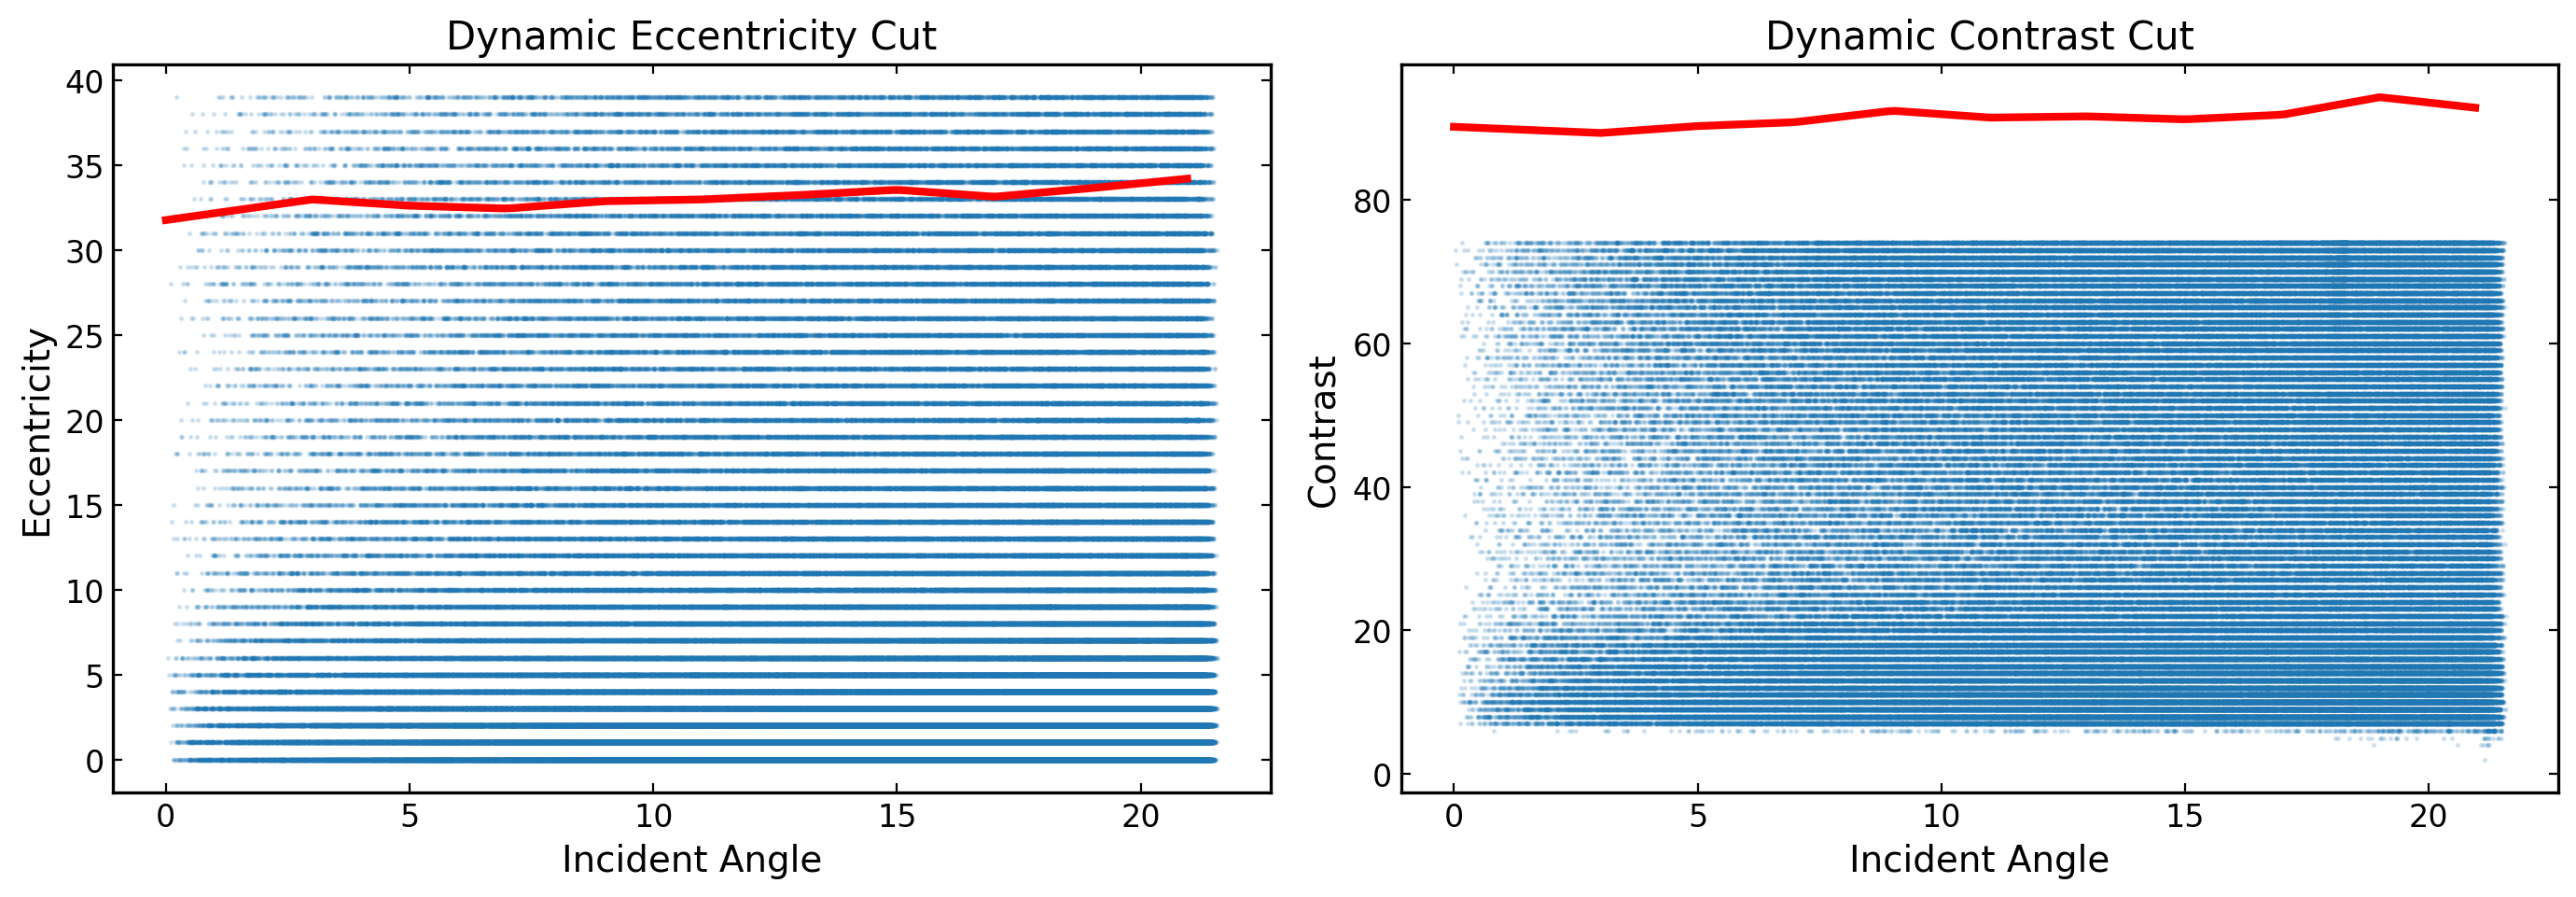

In [18]:
fig,axs=plt.subplots(

    1,

    2,

    figsize=(14,5)

)

axs[0].scatter(

    tracks.theta_inc_deg,

    tracks.e,

    s=1,

    alpha=.15

)

x=np.linspace(0,30,200)

axs[0].plot(

    x,

    ecc_limit(x),

    color="red",

    lw=3

)

axs[0].set_xlabel("Incident Angle")

axs[0].set_ylabel("Eccentricity")

axs[0].set_title("Dynamic Eccentricity Cut")

# ---------------------------------------------------

axs[1].scatter(

    tracks.theta_inc_deg,

    tracks.c,

    s=1,

    alpha=.15

)

axs[1].plot(

    x,

    contrast_limit(x),

    color="red",

    lw=3

)

axs[1].set_xlabel("Incident Angle")

axs[1].set_ylabel("Contrast")

axs[1].set_title("Dynamic Contrast Cut")

plt.tight_layout()

savefig("dynamic_acceptance.png")

plt.show()

In [19]:
# =============================================================================
# SIGNAL / BACKGROUND REGIONS
# =============================================================================

# Work only with dynamically accepted tracks
tr = tracks.loc[tracks.pass_dynamic].copy()

# -----------------------------
# Signal Region
# -----------------------------
signal = tr[
    (tr.r_cm <= SIG_R_MAX)
].copy()

# -----------------------------
# Background Region
# -----------------------------
background = tr[
    (tr.r_cm > BG_R_MIN) &
    (tr.r_cm <= BG_R_MAX)
].copy()

print("="*70)
print("REGION STATISTICS")
print("="*70)

print(f"Signal tracks      : {len(signal):,}")
print(f"Background tracks  : {len(background):,}")


REGION STATISTICS
Signal tracks      : 130,823
Background tracks  : 98,002


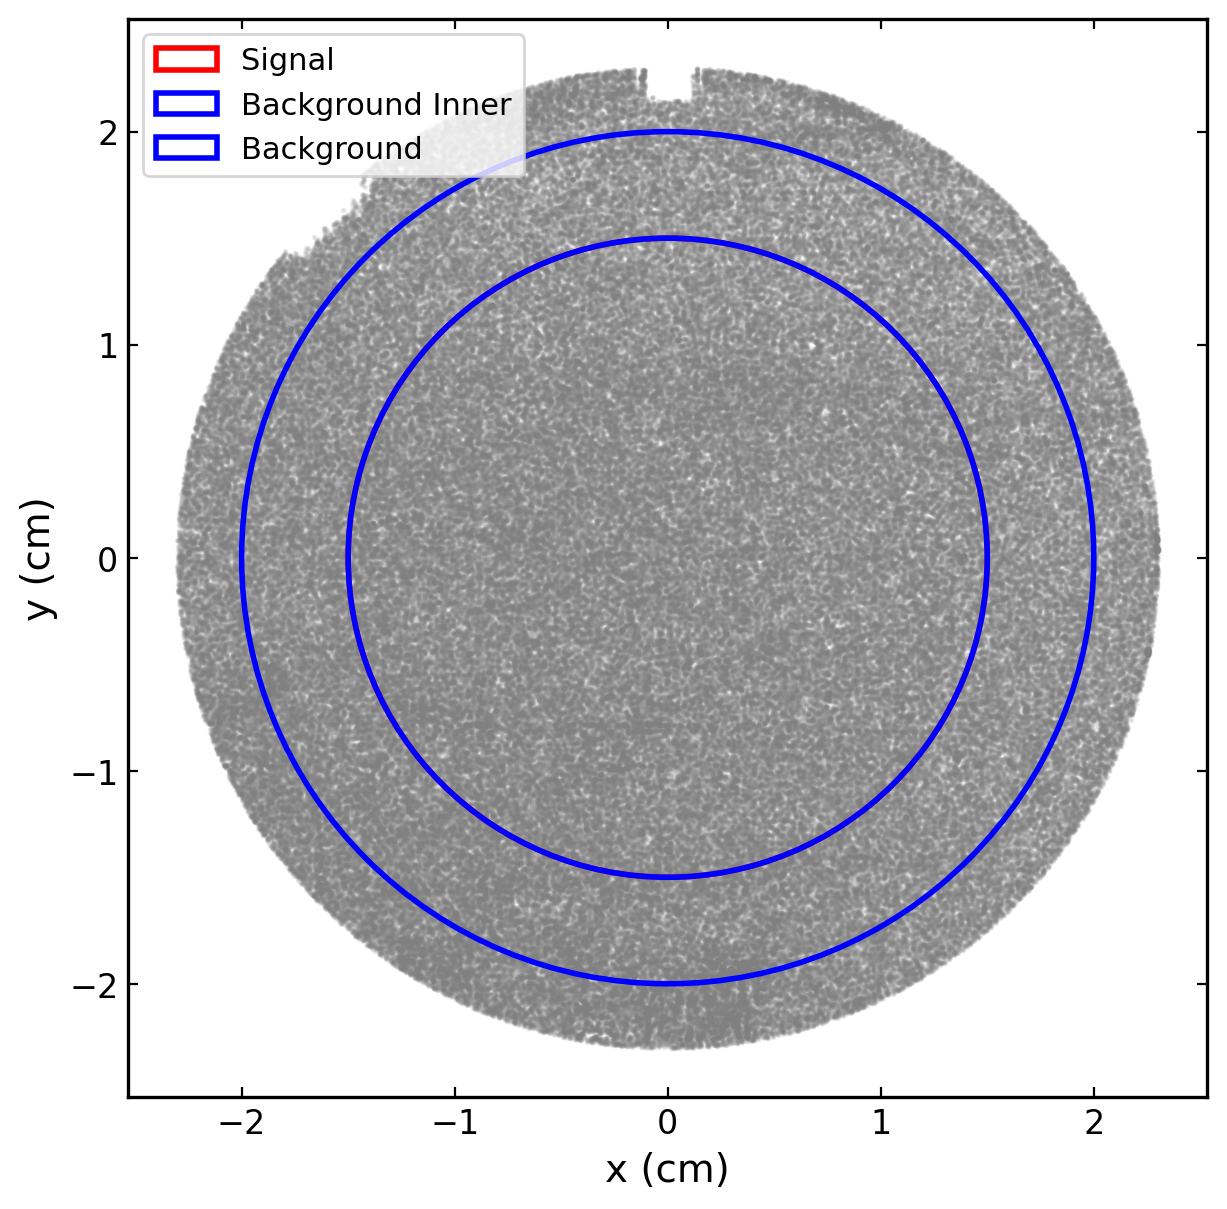

In [20]:
# =============================================================================
# REGION VISUALIZATION
# =============================================================================

fig,ax=plt.subplots(figsize=(7,7))

ax.scatter(
    tr.x,
    tr.y,
    s=1,
    alpha=.15,
    color="grey"
)

signal_box = patches.Circle(
    (0,0),
    SIG_R_MAX,
    fill=False,
    lw=2,
    color="red",
    label="Signal"
)

background_box_inner = patches.Circle(
    (0,0),
    BG_R_MIN,
    fill=False,
    edgecolor="blue",
    lw=2,
    label="Background Inner"
)
background_box_outer = patches.Circle(
    (0,0),
    BG_R_MAX,
    fill=False,
    lw=2,
    color="blue",
    label="Background"
)

ax.add_patch(signal_box)
ax.add_patch(background_box_inner)
ax.add_patch(background_box_outer)

ax.set_aspect("equal")

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")

ax.legend()

savefig("signal_background_regions.png")

plt.show()


Signal Area      : 7.0686 cm²
Background Area  : 5.4978 cm²
Scale Factor     : 1.2857


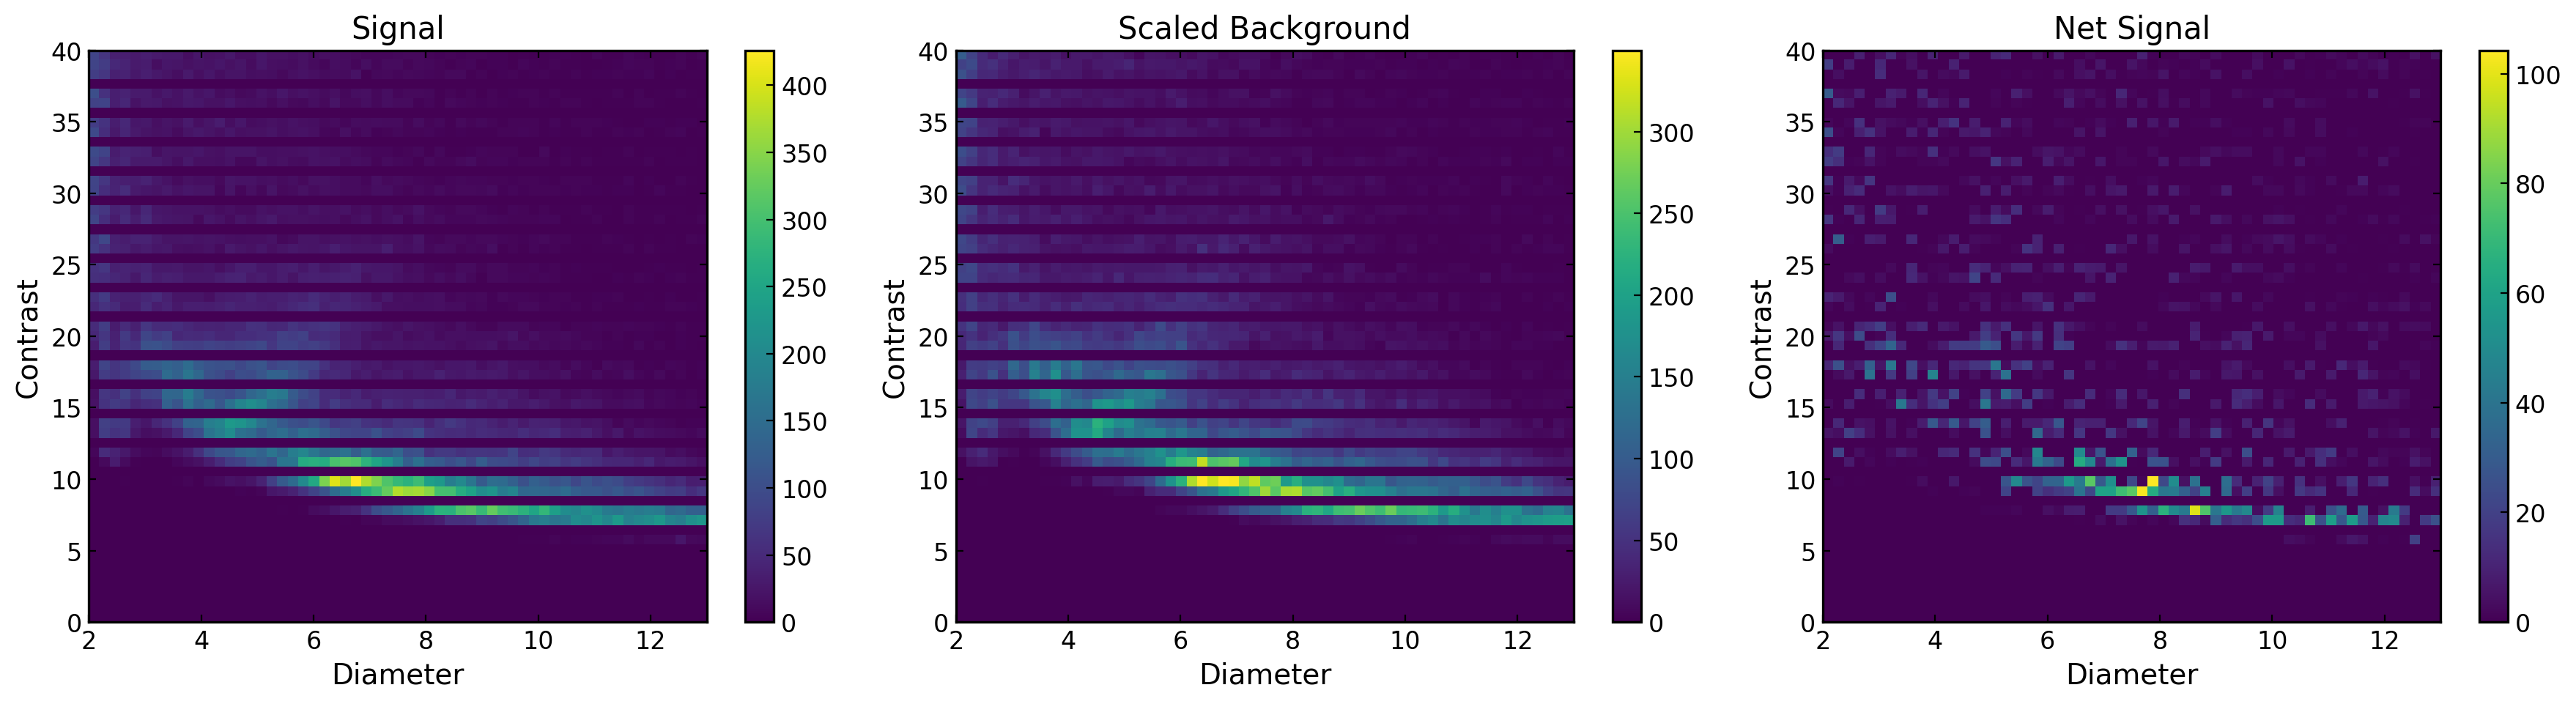

In [21]:
# =============================================================================
# AREA CALCULATION
# =============================================================================

signal_area = np.pi * (SIG_R_MAX**2)

background_area = np.pi * (BG_R_MAX**2 - BG_R_MIN**2)

area_scale = signal_area/background_area
alpha_bg = area_scale

print(f"Signal Area      : {signal_area:.4f} cm²")
print(f"Background Area  : {background_area:.4f} cm²")
print(f"Scale Factor     : {area_scale:.4f}")

# =============================================================================
# 2D BACKGROUND MAP
# =============================================================================

bins_d = np.linspace(D_MIN,D_MAX,60)
bins_c = np.linspace(0,40,60)

signal_hist,_,_ = np.histogram2d(
    signal.d,
    signal.c,
    bins=[bins_d,bins_c]
)

background_hist,_,_ = np.histogram2d(
    background.d,
    background.c,
    bins=[bins_d,bins_c]
)

background_scaled = background_hist * area_scale

net_hist = signal_hist - background_scaled

net_hist[net_hist<0]=0

# =============================================================================
# SIGNAL / BACKGROUND / NET
# =============================================================================

fig,axs=plt.subplots(1,3,figsize=(18,5))

extent=[
    bins_d[0],bins_d[-1],
    bins_c[0],bins_c[-1]
]

im=axs[0].imshow(
    signal_hist.T,
    origin="lower",
    extent=extent,
    aspect="auto"
)

axs[0].set_title("Signal")

plt.colorbar(im,ax=axs[0])

# ----------------------------

im=axs[1].imshow(
    background_scaled.T,
    origin="lower",
    extent=extent,
    aspect="auto"
)

axs[1].set_title("Scaled Background")

plt.colorbar(im,ax=axs[1])

# ----------------------------

im=axs[2].imshow(
    net_hist.T,
    origin="lower",
    extent=extent,
    aspect="auto"
)

axs[2].set_title("Net Signal")

plt.colorbar(im,ax=axs[2])

for ax in axs:

    ax.set_xlabel("Diameter")

    ax.set_ylabel("Contrast")

plt.tight_layout()

savefig("background_subtraction.png")

plt.show()

In [22]:
# =============================================================================
# NET PROTON YIELD
# =============================================================================

N_signal = len(signal)

N_background = len(background)*area_scale

N_net = N_signal - N_background

sigma_signal = np.sqrt(len(signal))
sigma_background = np.sqrt(len(background))*area_scale

sigma_net = np.sqrt(
    sigma_signal**2 +
    sigma_background**2
)

print("="*70)
print("NET PROTON YIELD")
print("="*70)

print(f"Signal counts        : {N_signal:.1f}")
print(f"Scaled background    : {N_background:.1f}")
print(f"Net counts           : {N_net:.1f}")
print(f"Statistical error    : ±{sigma_net:.2f}")

NET PROTON YIELD
Signal counts        : 130823.0
Scaled background    : 126002.6
Net counts           : 4820.4
Statistical error    : ±541.13


In [23]:
# =============================================================================
# ACCEPTANCE DIAGNOSTICS
# =============================================================================

print("="*70)
print("ACCEPTANCE DIAGNOSTICS")
print("="*70)

old_signal = tracks.loc[
    tracks.pass_old &
    (tracks.r_cm<=SIG_R_MAX)
]

new_signal = tr.loc[
    (tr.r_cm<=SIG_R_MAX)
]

old_background = tracks.loc[
    tracks.pass_old &
    (tracks.r_cm>BG_R_MIN)&
    (tracks.r_cm<=BG_R_MAX)
]

new_background = tr.loc[
    (tr.r_cm>BG_R_MIN)&
    (tr.r_cm<=BG_R_MAX)
]

print(f"Old Signal      : {len(old_signal):6d}")
print(f"New Signal      : {len(new_signal):6d}")

print()

print(f"Old Background  : {len(old_background):6d}")
print(f"New Background  : {len(new_background):6d}")

print()

print(f"Signal Gain     : {100*(len(new_signal)-len(old_signal))/max(len(old_signal),1):.2f}%")

print(f"Background Gain : {100*(len(new_background)-len(old_background))/max(len(old_background),1):.2f}%")

ACCEPTANCE DIAGNOSTICS
Old Signal      :  53019
New Signal      : 130823

Old Background  :  37887
New Background  :  98002

Signal Gain     : 146.75%
Background Gain : 158.67%


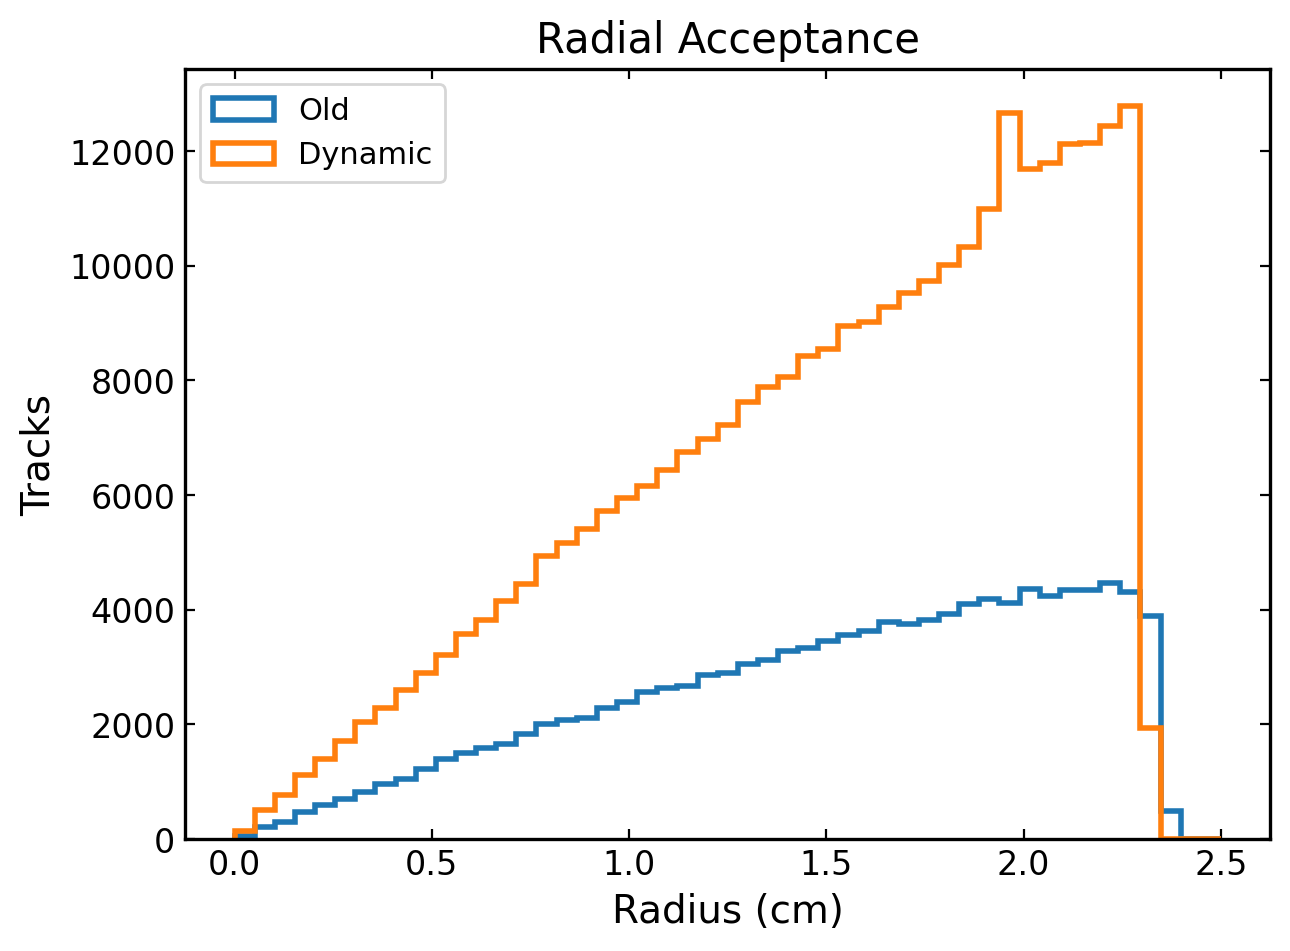

In [24]:
# =============================================================================
# RADIAL ACCEPTANCE
# =============================================================================

fig,ax=plt.subplots(figsize=(7,5))

r=np.linspace(
    0,
    CR39_RADIUS_CM,
    50
)

ax.hist(

    tracks.loc[
        tracks.pass_old,
        "r_cm"
    ],

    bins=r,

    histtype="step",

    lw=2,

    label="Old"

)

ax.hist(

    tr.r_cm,

    bins=r,

    histtype="step",

    lw=2,

    label="Dynamic"

)

ax.legend()

ax.set_xlabel("Radius (cm)")

ax.set_ylabel("Tracks")

ax.set_title("Radial Acceptance")

savefig("radial_acceptance.png")

plt.show()

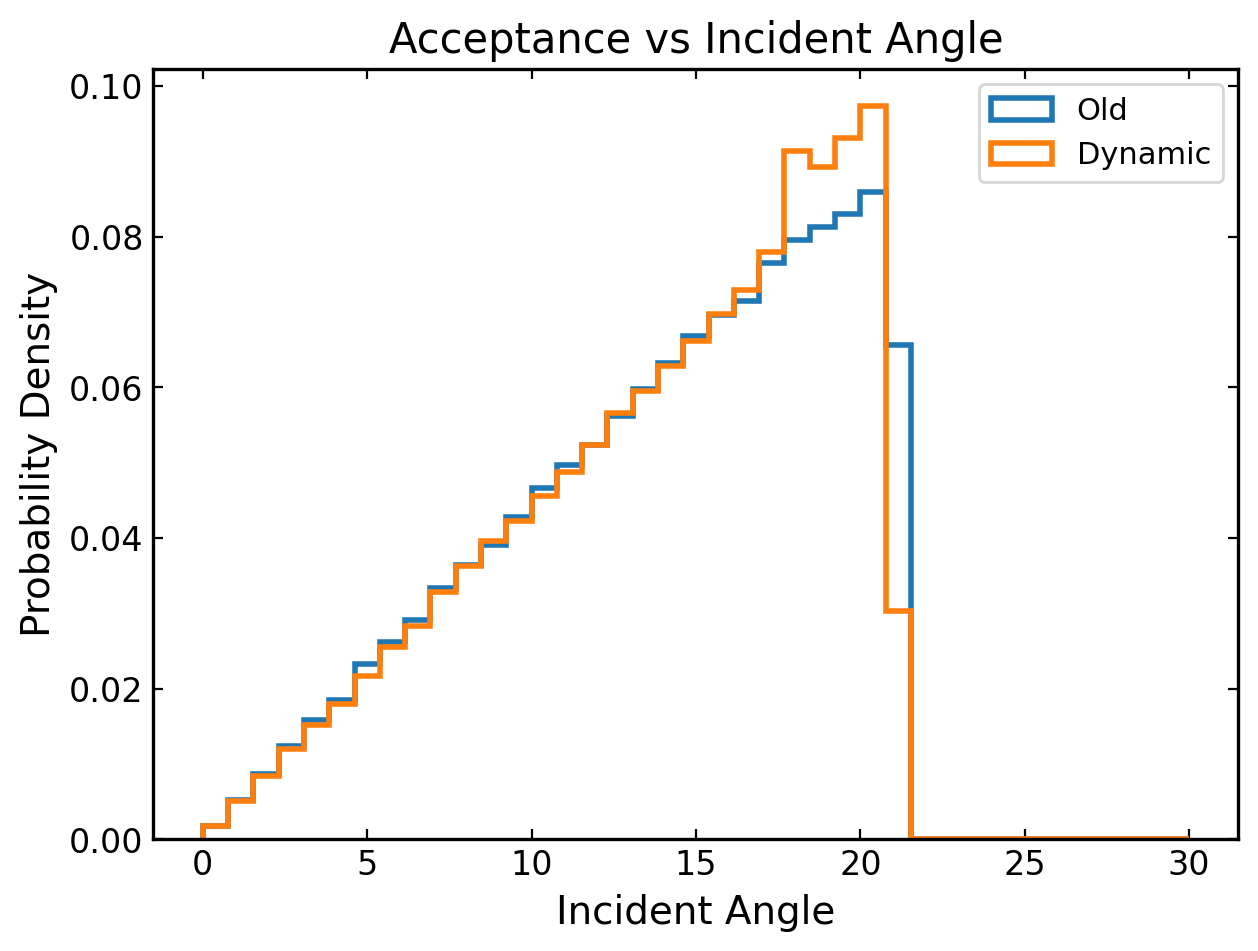

In [25]:
# =============================================================================
# INCIDENT ANGLE ACCEPTANCE
# =============================================================================

fig,ax=plt.subplots(figsize=(7,5))

bins=np.linspace(
    0,
    30,
    40
)

ax.hist(

    tracks.loc[
        tracks.pass_old,
        "theta_inc_deg"
    ],

    bins=bins,

    density=True,

    histtype="step",

    lw=2,

    label="Old"

)

ax.hist(

    tr.theta_inc_deg,

    bins=bins,

    density=True,

    histtype="step",

    lw=2,

    label="Dynamic"

)

ax.legend()

ax.set_xlabel("Incident Angle")

ax.set_ylabel("Probability Density")

ax.set_title("Acceptance vs Incident Angle")

savefig("theta_acceptance.png")

plt.show()

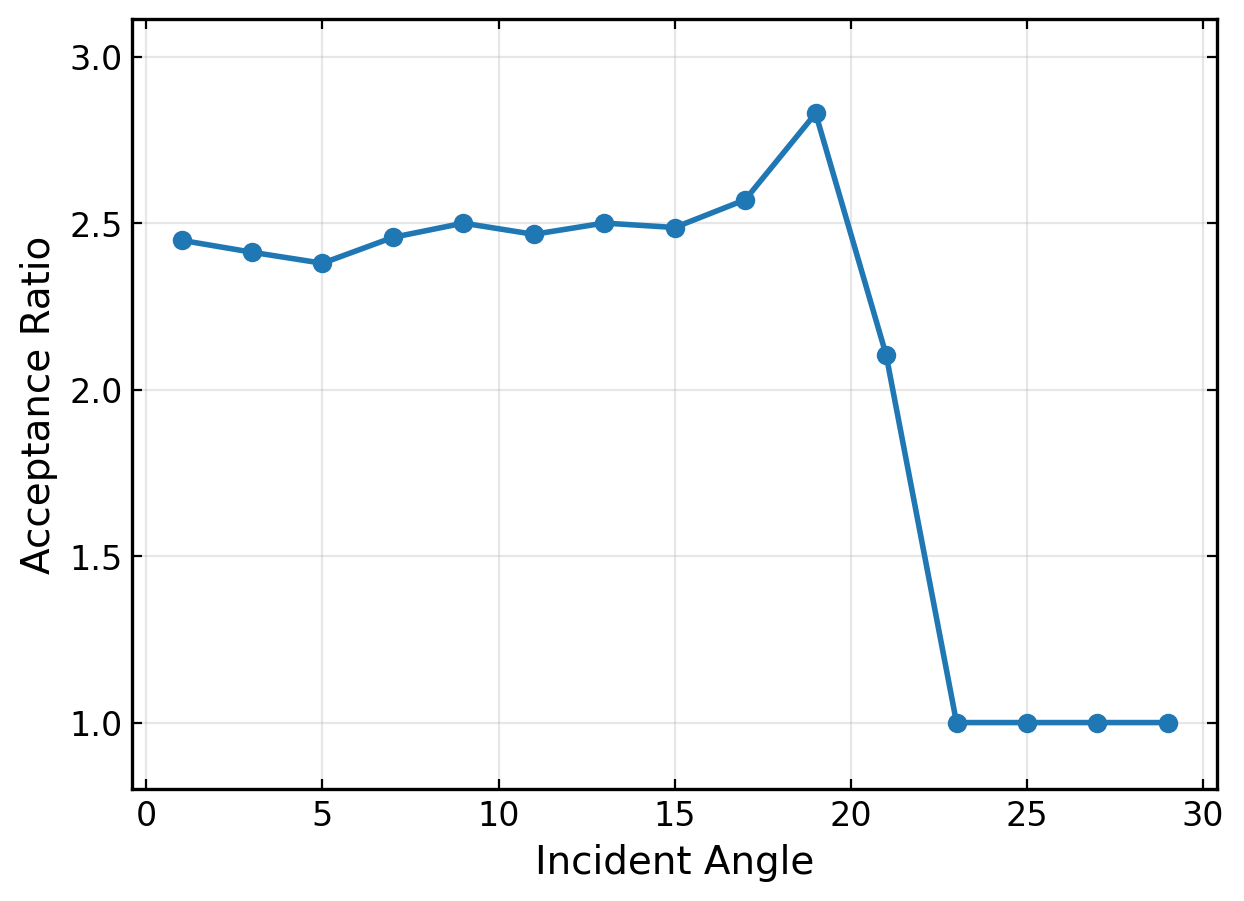

In [26]:
# =============================================================================
# ACCEPTANCE FRACTION
# =============================================================================

theta_bins=np.arange(
    0,
    31,
    2
)

old=np.histogram(

    tracks.loc[
        tracks.pass_old,
        "theta_inc_deg"
    ],

    theta_bins

)[0]

new=np.histogram(

    tr.theta_inc_deg,

    theta_bins

)[0]

fraction=np.divide(

    new,

    old,

    out=np.ones_like(new,dtype=float),

    where=old>0

)

theta_center=.5*(theta_bins[1:]+theta_bins[:-1])

fig,ax=plt.subplots(figsize=(7,5))

ax.plot(

    theta_center,

    fraction,

    "o-"

)

ax.set_xlabel("Incident Angle")

ax.set_ylabel("Acceptance Ratio")

ax.set_ylim(0.8,max(1.1,fraction.max()*1.1))

ax.grid(alpha=.3)

savefig("acceptance_ratio.png")

plt.show()


RECOVERED TRACKS
Recovered : 184,666


,frame_number,d,x,y,e,c,a,r_cm,theta_inc_rad,theta_inc_deg,cos_theta,sin_theta,theta_bin,pass_old,pass_dynamic_e,pass_dynamic_c,pass_dynamic,pass_e,pass_c
607,258,3.96880,-0.335698,2.268231,19,58,72,2.292938,0.365030,20.914671,0.934113,0.356977,"(20, 22]",False,True,False,True,True,True
608,258,2.02704,-0.363938,2.268329,2,45,64,2.297339,0.365670,20.951338,0.933884,0.357575,"(20, 22]",False,True,False,True,True,True
609,258,3.13896,-0.342225,2.268952,34,15,50,2.294616,0.365274,20.928654,0.934026,0.357205,"(20, 22]",False,False,True,True,True,True
611,258,3.73592,-0.330056,2.269313,31,56,75,2.293190,0.365066,20.916767,0.934100,0.357011,"(20, 22]",False,False,False,True,True,True
612,258,2.39768,-0.344521,2.270921,32,73,80,2.296906,0.365607,20.947725,0.933907,0.357516,"(20, 22]",False,False,False,True,True,True


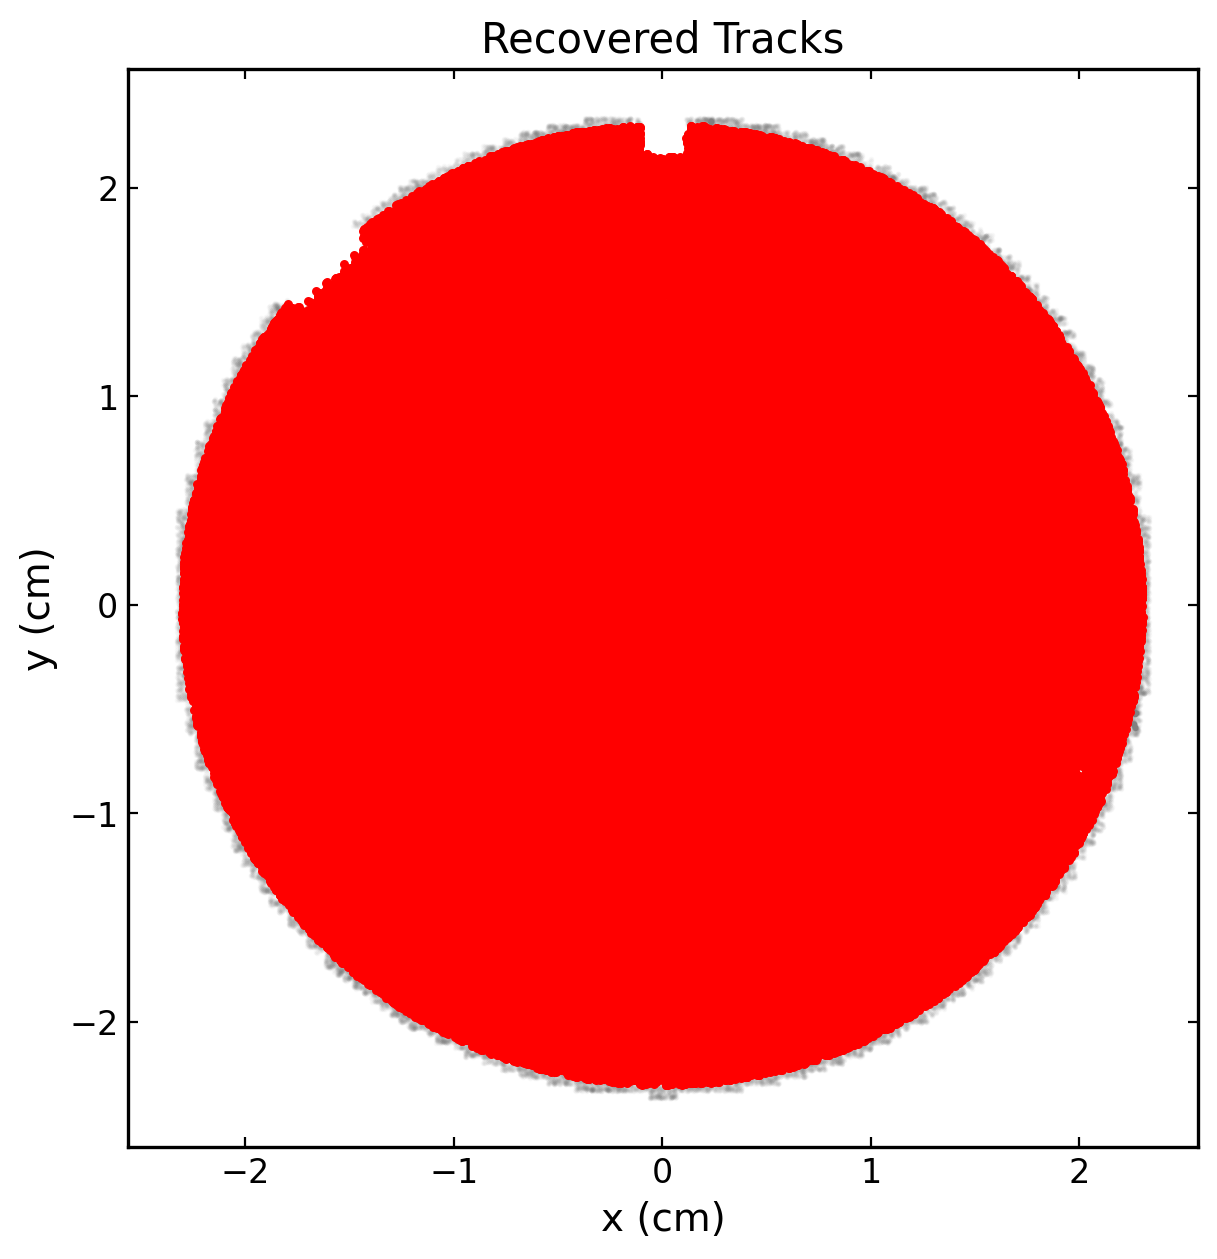

In [27]:
# =============================================================================
# RECOVERED TRACKS
# =============================================================================

recovered=tracks.loc[
    (~tracks.pass_old)&
    (tracks.pass_dynamic)
]

print()

print("="*70)

print("RECOVERED TRACKS")

print("="*70)

print(f"Recovered : {len(recovered):,}")

display(recovered.head())

# =============================================================================
# LOCATION OF RECOVERED TRACKS
# =============================================================================

fig,ax=plt.subplots(figsize=(7,7))

ax.scatter(

    tracks.x,

    tracks.y,

    s=1,

    alpha=.05,

    color="grey"

)

ax.scatter(

    recovered.x,

    recovered.y,

    s=5,

    color="red"

)

ax.set_aspect("equal")

ax.set_xlabel("x (cm)")

ax.set_ylabel("y (cm)")

ax.set_title("Recovered Tracks")

savefig("recovered_tracks.png")

plt.show()

In [28]:
# =============================================================================
# GLOBAL MORPHOLOGY OPTIMIZATION
#
# We optimize ONE global eccentricity and contrast threshold using the
# signal box and background notch.
#
# After obtaining the optimum morphology cuts, we will study their
# angular behaviour.
# =============================================================================

signal_all = tracks.loc[(tracks.r_cm <= SIG_R_MAX)].copy()

background_all = tracks.loc[(tracks.r_cm > BG_R_MIN) & (tracks.r_cm <= BG_R_MAX)].copy()

print("="*70)
print("GLOBAL OPTIMIZATION")
print("="*70)

print(f"Signal tracks     : {len(signal_all):,}")
print(f"Background tracks : {len(background_all):,}")

print()

print(f"Area scale = {alpha_bg:.5f}")

# =============================================================================
# THRESHOLD GRID
# =============================================================================

E_THRESHOLDS = np.arange(5,31,1)

C_THRESHOLDS = np.arange(5,61,1)

Z_grid = np.zeros(

    (
        len(E_THRESHOLDS),
        len(C_THRESHOLDS)
    )

)

NET_grid = np.zeros_like(Z_grid)

SB_grid = np.zeros_like(Z_grid)

print(Z_grid.shape)

# =============================================================================
# GRID SEARCH
# =============================================================================

best = None

for ie,e_cut in enumerate(E_THRESHOLDS):

    for ic,c_cut in enumerate(C_THRESHOLDS):

        Ns = np.count_nonzero(

            (signal_all.e<=e_cut) &
            (signal_all.c<=c_cut)

        )

        Nb = np.count_nonzero(

            (background_all.e<=e_cut) &
            (background_all.c<=c_cut)

        )

        B = alpha_bg*Nb

        Net = Ns-B

        sigma=np.sqrt(

            Ns+

            alpha_bg**2*Nb

        )

        if sigma==0:

            continue

        Z=Net/sigma

        SB=Net/B if B>0 else np.nan

        Z_grid[ie,ic]=Z

        NET_grid[ie,ic]=Net

        SB_grid[ie,ic]=SB

        if best is None:

            best=dict(

                e=e_cut,

                c=c_cut,

                Z=Z,

                Net=Net,

                Ns=Ns,

                Nb=Nb,

                SB=SB

            )

        elif Z>best["Z"]:

            best=dict(

                e=e_cut,

                c=c_cut,

                Z=Z,

                Net=Net,

                Ns=Ns,

                Nb=Nb,

                SB=SB

            )

# =============================================================================
# RESULTS
# =============================================================================

print("="*70)

print("BEST MORPHOLOGY CUTS")

print("="*70)

for k,v in best.items():

    print(f"{k:10s} : {v}")

GLOBAL OPTIMIZATION
Signal tracks     : 136,481
Background tracks : 101,984

Area scale = 1.28571
(26, 56)
BEST MORPHOLOGY CUTS
e          : 12
c          : 11
Z          : 13.807666567377412
Net        : 3568.428571428569
Ns         : 31228
Nb         : 21513
SB         : 0.12901243175960778


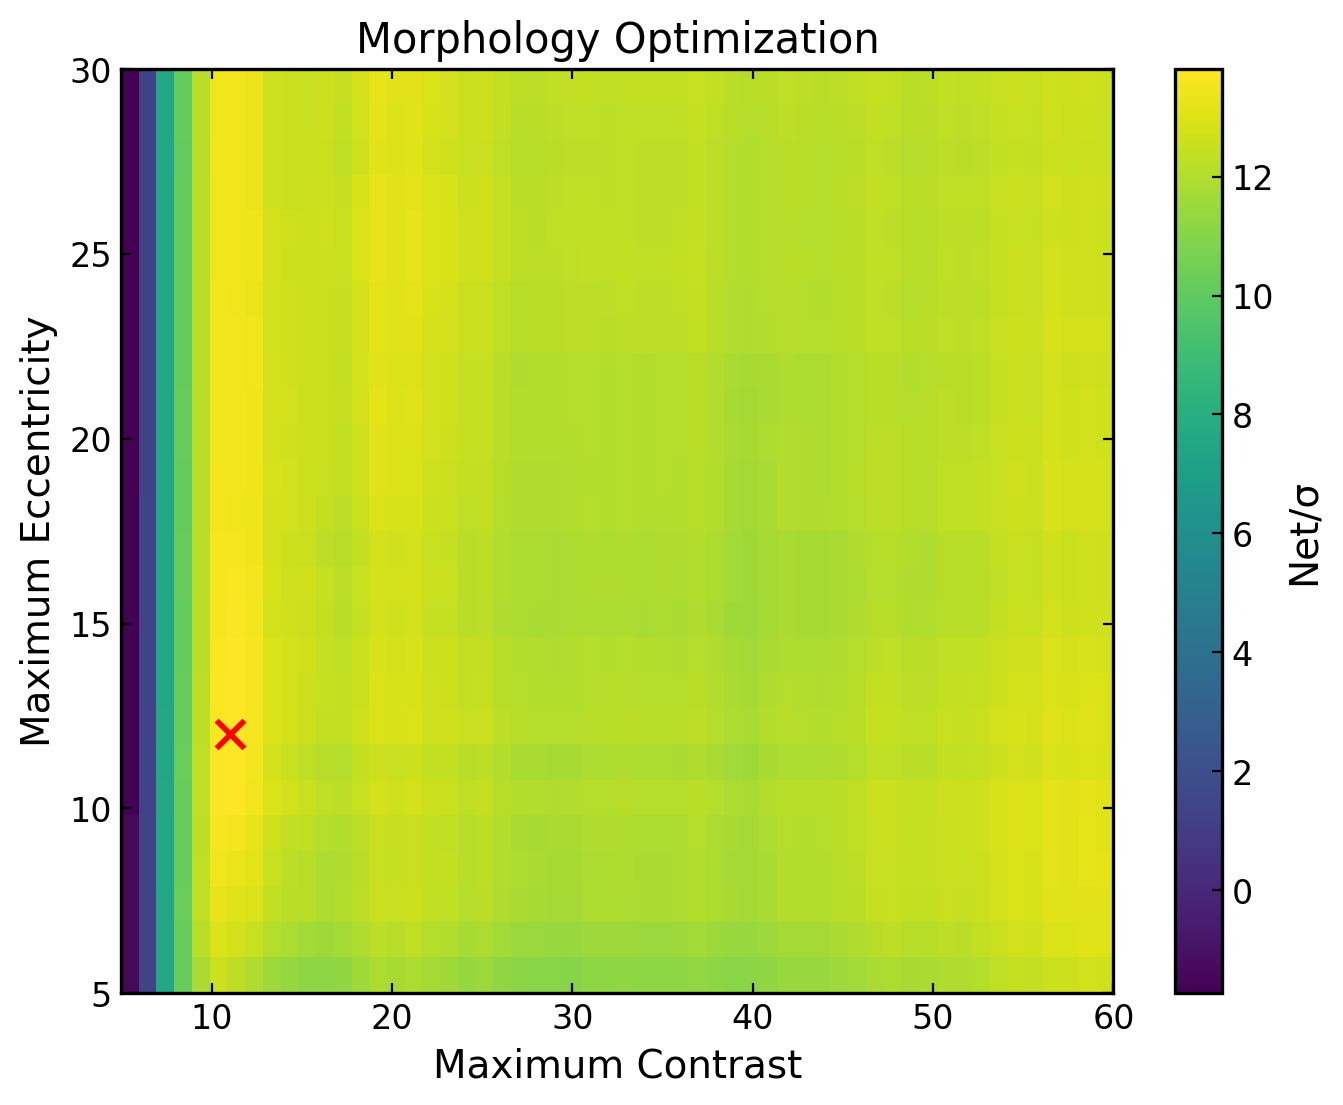

In [29]:
# =============================================================================
# SIGNIFICANCE HEATMAP
# =============================================================================

plt.figure(figsize=(8,6))

im=plt.imshow(

    Z_grid,

    origin="lower",

    aspect="auto",

    extent=[

        C_THRESHOLDS.min(),

        C_THRESHOLDS.max(),

        E_THRESHOLDS.min(),

        E_THRESHOLDS.max()

    ]

)

plt.colorbar(

    im,

    label="Net/σ"

)

plt.scatter(

    best["c"],

    best["e"],

    color="red",

    s=100,

    marker="x"

)

plt.xlabel("Maximum Contrast")

plt.ylabel("Maximum Eccentricity")

plt.title("Morphology Optimization")

savefig("optimization_heatmap.png")

plt.show()

In [30]:
# =============================================================================
# APPLY OPTIMUM CUT
# =============================================================================

tracks["pass_optimum"]=(

    (tracks.e<=best["e"]) &

    (tracks.c<=best["c"])

)

tr=tracks.loc[
    tracks.pass_optimum
].copy()

print()

print(f"Tracks kept : {len(tr):,}")

print(f"Fraction    : {100*len(tr)/len(tracks):.2f}%")


Tracks kept : 68,515
Fraction    : 21.01%


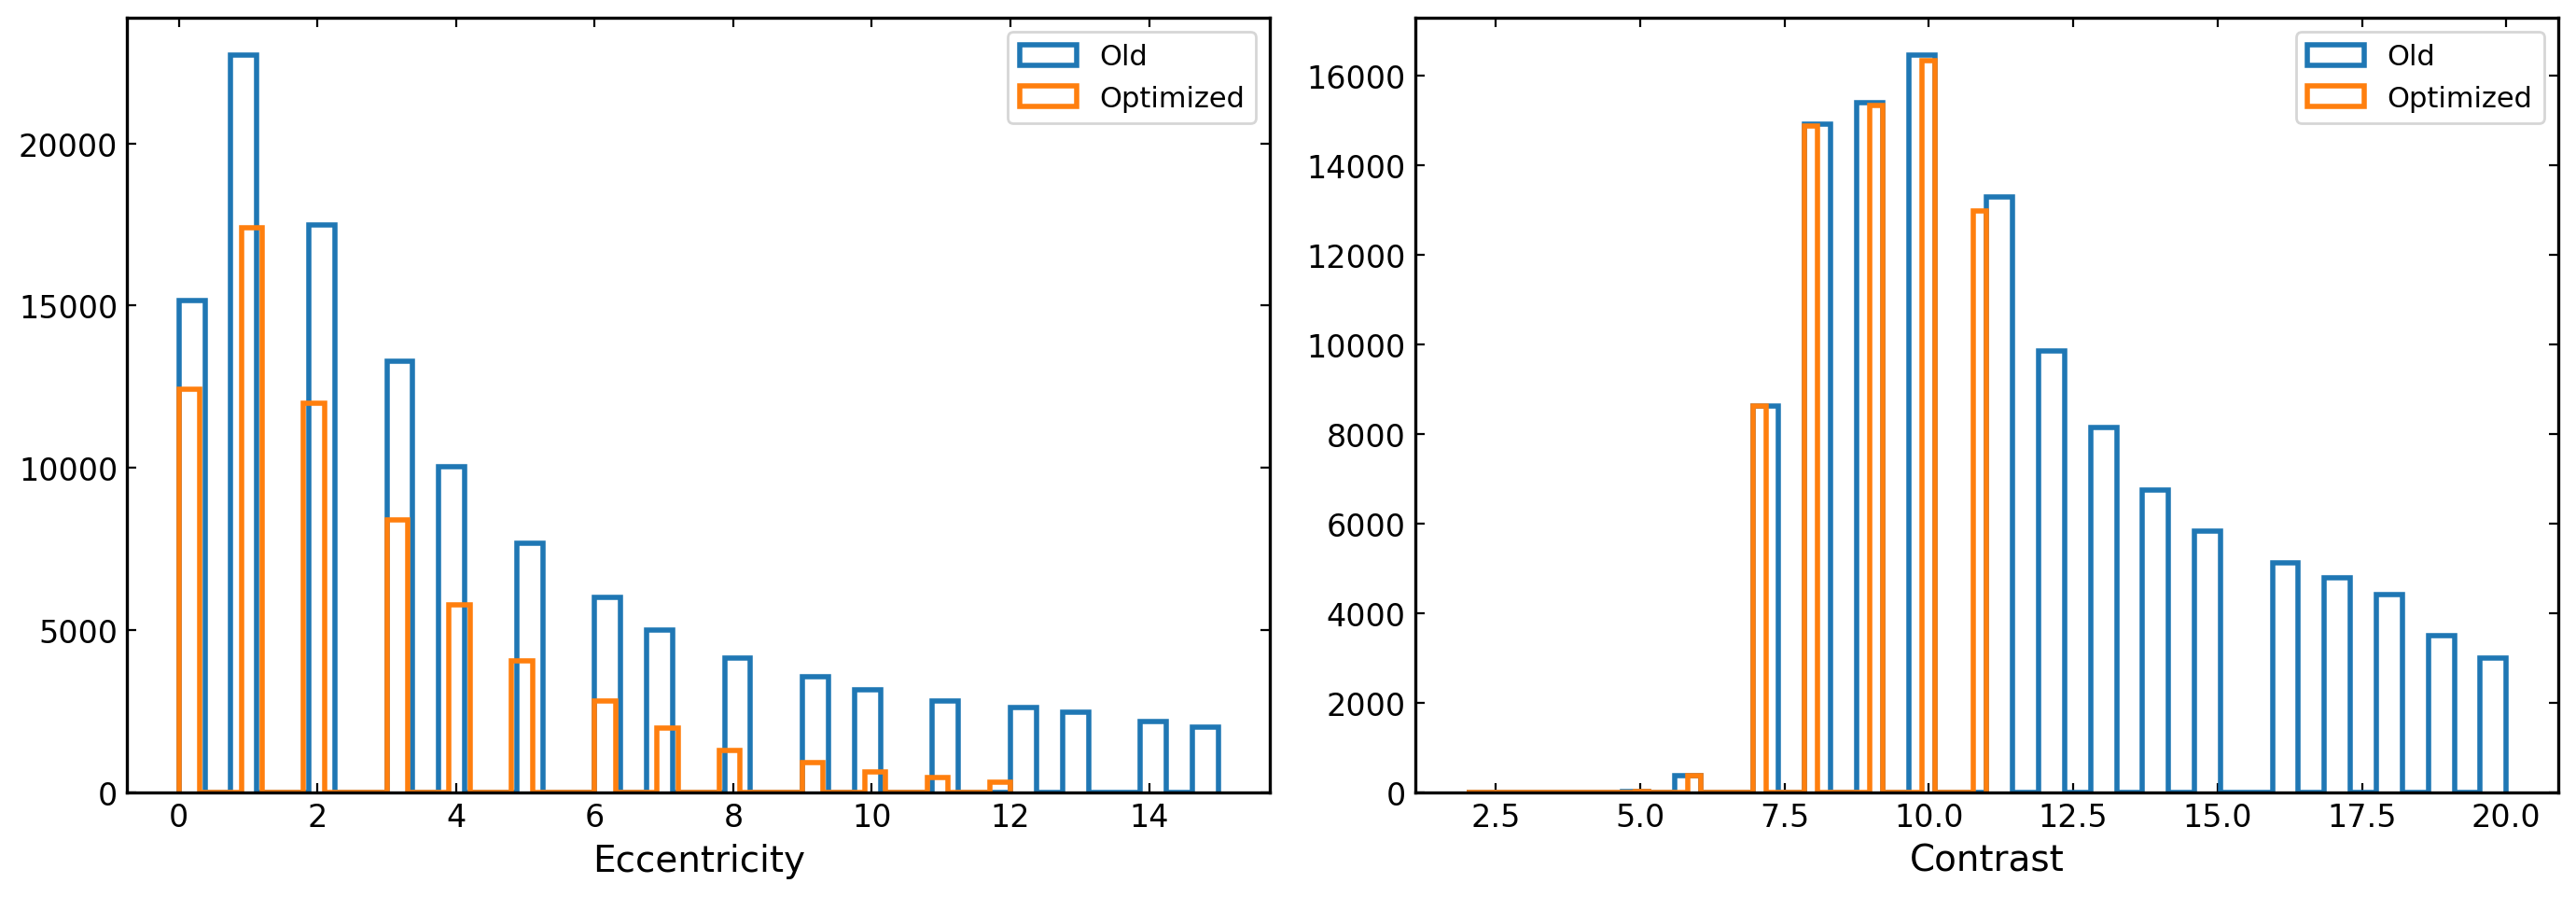

In [31]:
# =============================================================================
# COMPARISON
# =============================================================================

old=tracks.loc[
    tracks.pass_old
]

new=tracks.loc[
    tracks.pass_optimum
]

fig,axs=plt.subplots(

    1,

    2,

    figsize=(14,5)

)

axs[0].hist(

    old.e,

    bins=40,

    histtype="step",

    lw=2,

    label="Old"

)

axs[0].hist(

    new.e,

    bins=40,

    histtype="step",

    lw=2,

    label="Optimized"

)

axs[0].legend()

axs[0].set_xlabel("Eccentricity")

# --------------------------------------------

axs[1].hist(

    old.c,

    bins=40,

    histtype="step",

    lw=2,

    label="Old"

)

axs[1].hist(

    new.c,

    bins=40,

    histtype="step",

    lw=2,

    label="Optimized"

)

axs[1].legend()

axs[1].set_xlabel("Contrast")

plt.tight_layout()

savefig("optimized_distributions.png")

plt.show()

In [32]:
# =============================================================================
# ECCENTRICITY IMPORTANCE
# =============================================================================

ecc_scan=[]

fixed_c = best["c"]

for e_cut in range(5,31):

    Ns = np.count_nonzero(

        (signal_all.e<=e_cut)&
        (signal_all.c<=fixed_c)

    )

    Nb = np.count_nonzero(

        (background_all.e<=e_cut)&
        (background_all.c<=fixed_c)

    )

    B = alpha_bg*Nb

    Net = Ns-B

    sigma=np.sqrt(

        Ns+

        alpha_bg**2*Nb

    )

    Z=Net/sigma if sigma>0 else np.nan

    Purity=Net/B if B>0 else np.nan

    ecc_scan.append({

        "e":e_cut,

        "Signal":Ns,

        "Background":B,

        "Net":Net,

        "Z":Z,

        "Purity":Purity

    })

ecc_scan=pd.DataFrame(ecc_scan)

display(ecc_scan)

,e,Signal,Background,Net,Z,Purity
0,5,27268,24296.142857,2971.857143,12.286498,0.122318
1,6,28592,25419.857143,3172.142857,12.814812,0.124790
2,7,29495,26211.857143,3283.142857,13.060059,0.125254
3,8,30116,26718.428571,3397.571429,13.381217,0.127162
4,9,30542,27086.142857,3455.857143,13.516877,0.127588
5,10,30870,27325.285714,3544.714286,13.797519,0.129723
6,11,31081,27527.142857,3553.857143,13.784061,0.129104
7,12,31228,27659.571429,3568.428571,13.807667,0.129012
8,13,31334,27761.142857,3572.857143,13.800381,0.128700
9,14,31410,27840.857143,3569.142857,13.767716,0.128198


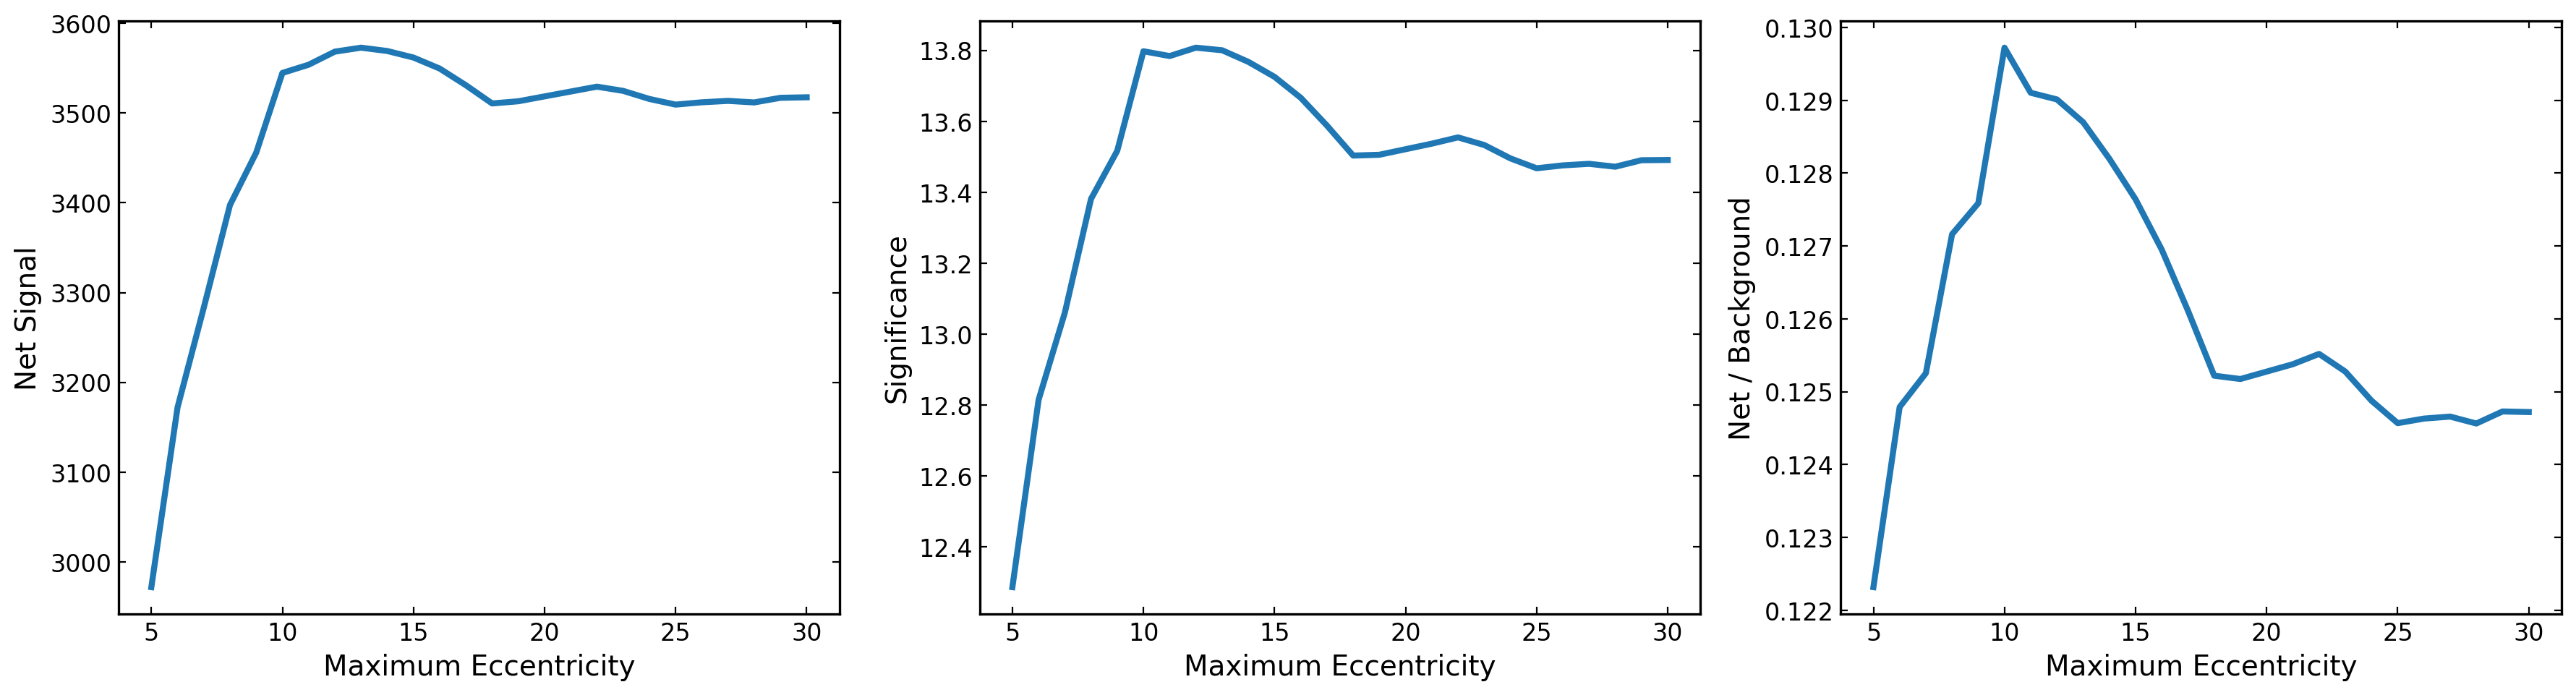

In [33]:
# =============================================================================
# ECCENTRICITY SCAN
# =============================================================================

fig,axs=plt.subplots(

    1,

    3,

    figsize=(18,5)

)

# ----------------------------

axs[0].plot(

    ecc_scan.e,

    ecc_scan.Net,

    lw=3

)

axs[0].set_xlabel("Maximum Eccentricity")

axs[0].set_ylabel("Net Signal")

# ----------------------------

axs[1].plot(

    ecc_scan.e,

    ecc_scan.Z,

    lw=3

)

axs[1].set_xlabel("Maximum Eccentricity")

axs[1].set_ylabel("Significance")

# ----------------------------

axs[2].plot(

    ecc_scan.e,

    ecc_scan.Purity,

    lw=3

)

axs[2].set_xlabel("Maximum Eccentricity")

axs[2].set_ylabel("Net / Background")

plt.tight_layout()

savefig("eccentricity_importance.png")

plt.show()

In [34]:
# =============================================================================
# CONTRAST IMPORTANCE
# =============================================================================

contrast_scan=[]

fixed_e = best["e"]

for c_cut in range(5,61):

    Ns=np.count_nonzero(

        (signal_all.e<=fixed_e)&
        (signal_all.c<=c_cut)

    )

    Nb=np.count_nonzero(

        (background_all.e<=fixed_e)&
        (background_all.c<=c_cut)

    )

    B=alpha_bg*Nb

    Net=Ns-B

    sigma=np.sqrt(

        Ns+

        alpha_bg**2*Nb

    )

    Z=Net/sigma if sigma>0 else np.nan

    Purity=Net/B if B>0 else np.nan

    contrast_scan.append({

        "c":c_cut,

        "Signal":Ns,

        "Background":B,

        "Net":Net,

        "Z":Z,

        "Purity":Purity

    })

contrast_scan=pd.DataFrame(
    contrast_scan
)

display(contrast_scan)

,c,Signal,Background,Net,Z,Purity
0,5,0,3.857143,-3.857143,-1.732051,-1.000000
1,6,137,113.142857,23.857143,1.419491,0.210859
2,7,4322,3601.285714,720.714286,7.617240,0.200127
3,8,11235,9668.571429,1566.428571,10.182349,0.162012
4,9,18295,15879.857143,2415.142857,12.274965,0.152088
5,10,25632,22439.571429,3192.428571,13.677010,0.142268
6,11,31228,27659.571429,3568.428571,13.807667,0.129012
7,12,35110,31380.428571,3729.571429,13.577233,0.118850
8,13,38094,34374.857143,3719.142857,12.964885,0.108194
9,14,40495,36695.571429,3799.428571,12.831586,0.103539


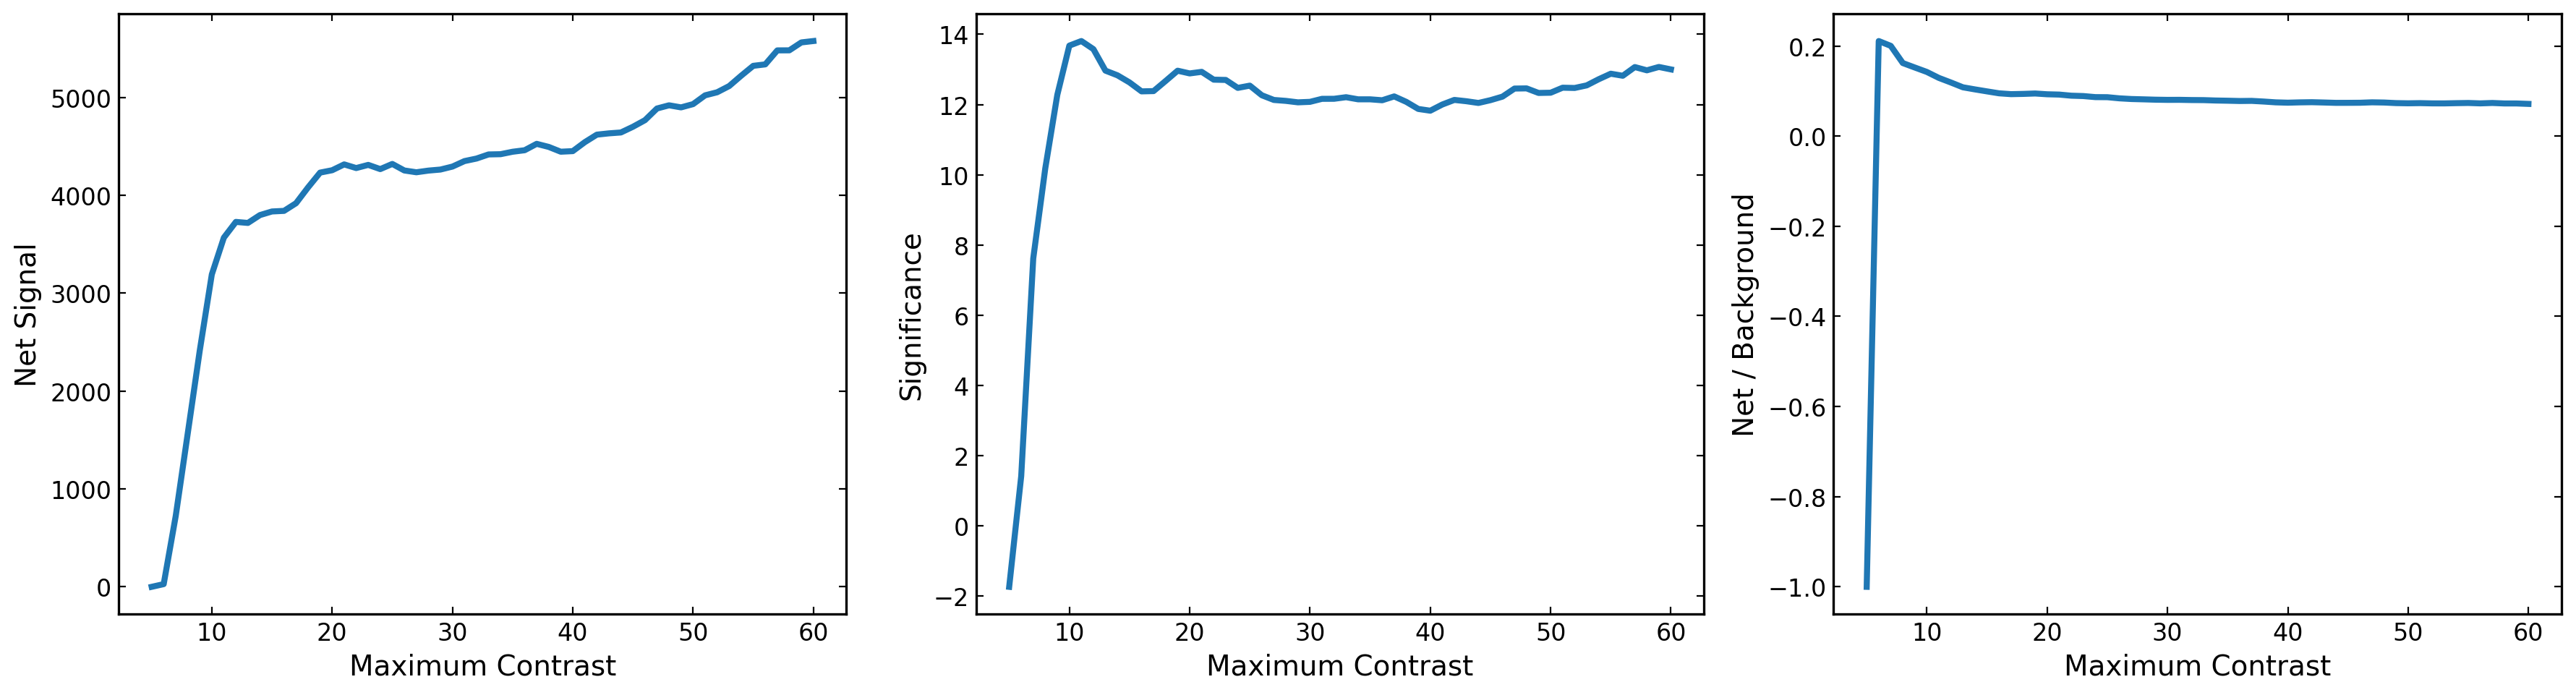

In [35]:
# =============================================================================
# CONTRAST SCAN
# =============================================================================

fig,axs=plt.subplots(

    1,

    3,

    figsize=(18,5)

)

axs[0].plot(

    contrast_scan.c,

    contrast_scan.Net,

    lw=3

)

axs[0].set_xlabel("Maximum Contrast")

axs[0].set_ylabel("Net Signal")

# --------------------------------

axs[1].plot(

    contrast_scan.c,

    contrast_scan.Z,

    lw=3

)

axs[1].set_xlabel("Maximum Contrast")

axs[1].set_ylabel("Significance")

# --------------------------------

axs[2].plot(

    contrast_scan.c,

    contrast_scan.Purity,

    lw=3

)

axs[2].set_xlabel("Maximum Contrast")

axs[2].set_ylabel("Net / Background")

plt.tight_layout()

savefig("contrast_importance.png")

plt.show()

In [36]:
# =============================================================================
# DIAMETER IMPORTANCE
# =============================================================================

diameter_scan=[]

fixed_e = best["e"]
fixed_c = best["c"]

for dmax in np.arange(6,15,0.25):

    Ns=np.count_nonzero(

        (signal_all.d>=D_MIN)&
        (signal_all.d<=dmax)&

        (signal_all.e<=fixed_e)&
        (signal_all.c<=fixed_c)

    )

    Nb=np.count_nonzero(

        (background_all.d>=D_MIN)&
        (background_all.d<=dmax)&

        (background_all.e<=fixed_e)&
        (background_all.c<=fixed_c)

    )

    B=alpha_bg*Nb

    Net=Ns-B

    sigma=np.sqrt(

        Ns+

        alpha_bg**2*Nb

    )

    Z=Net/sigma if sigma>0 else np.nan

    Purity=Net/B if B>0 else np.nan

    diameter_scan.append({

        "dmax":dmax,

        "Signal":Ns,

        "Background":B,

        "Net":Net,

        "Z":Z,

        "Purity":Purity

    })

diameter_scan=pd.DataFrame(
    diameter_scan
)

display(diameter_scan)

,dmax,Signal,Background,Net,Z,Purity
0,6.00,2389,2179.285714,209.714286,2.910751,0.096231
1,6.25,3334,2973.857143,360.142857,4.256898,0.121103
2,6.50,4428,4024.285714,403.714286,4.119945,0.100319
3,6.75,5707,5051.571429,655.428571,5.933515,0.129747
4,7.00,7024,6220.285714,803.714286,6.557600,0.129209
5,7.25,8304,7314.428571,989.571429,7.436338,0.135290
6,7.50,9588,8436.857143,1151.142857,8.052631,0.136442
7,7.75,10907,9563.142857,1343.857143,8.822385,0.140525
8,8.00,12225,10599.428571,1625.571429,10.110019,0.153364
9,8.25,13557,11707.714286,1849.285714,10.933187,0.157954


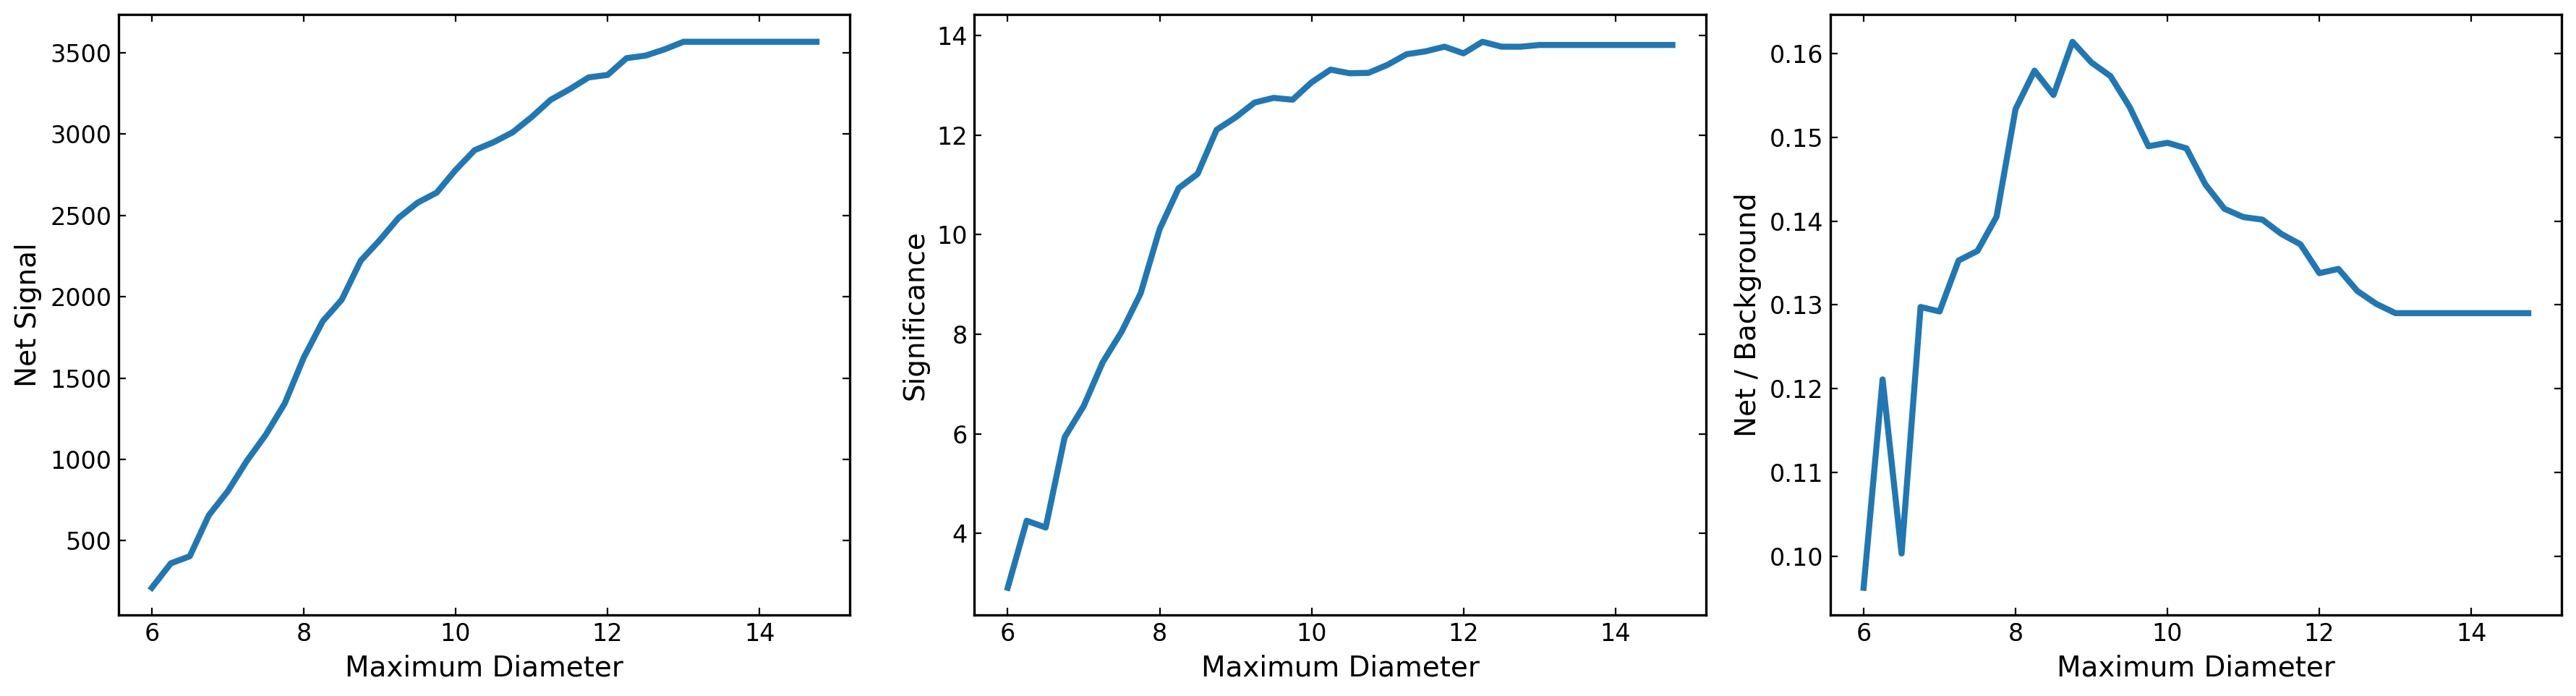

In [37]:
# =============================================================================
# DIAMETER SCAN
# =============================================================================

fig,axs=plt.subplots(

    1,

    3,

    figsize=(18,5)

)

axs[0].plot(

    diameter_scan.dmax,

    diameter_scan.Net,

    lw=3

)

axs[0].set_xlabel("Maximum Diameter")

axs[0].set_ylabel("Net Signal")

# ------------------------------

axs[1].plot(

    diameter_scan.dmax,

    diameter_scan.Z,

    lw=3

)

axs[1].set_xlabel("Maximum Diameter")

axs[1].set_ylabel("Significance")

# ------------------------------

axs[2].plot(

    diameter_scan.dmax,

    diameter_scan.Purity,

    lw=3

)

axs[2].set_xlabel("Maximum Diameter")

axs[2].set_ylabel("Net / Background")

plt.tight_layout()

savefig("diameter_importance.png")

plt.show()

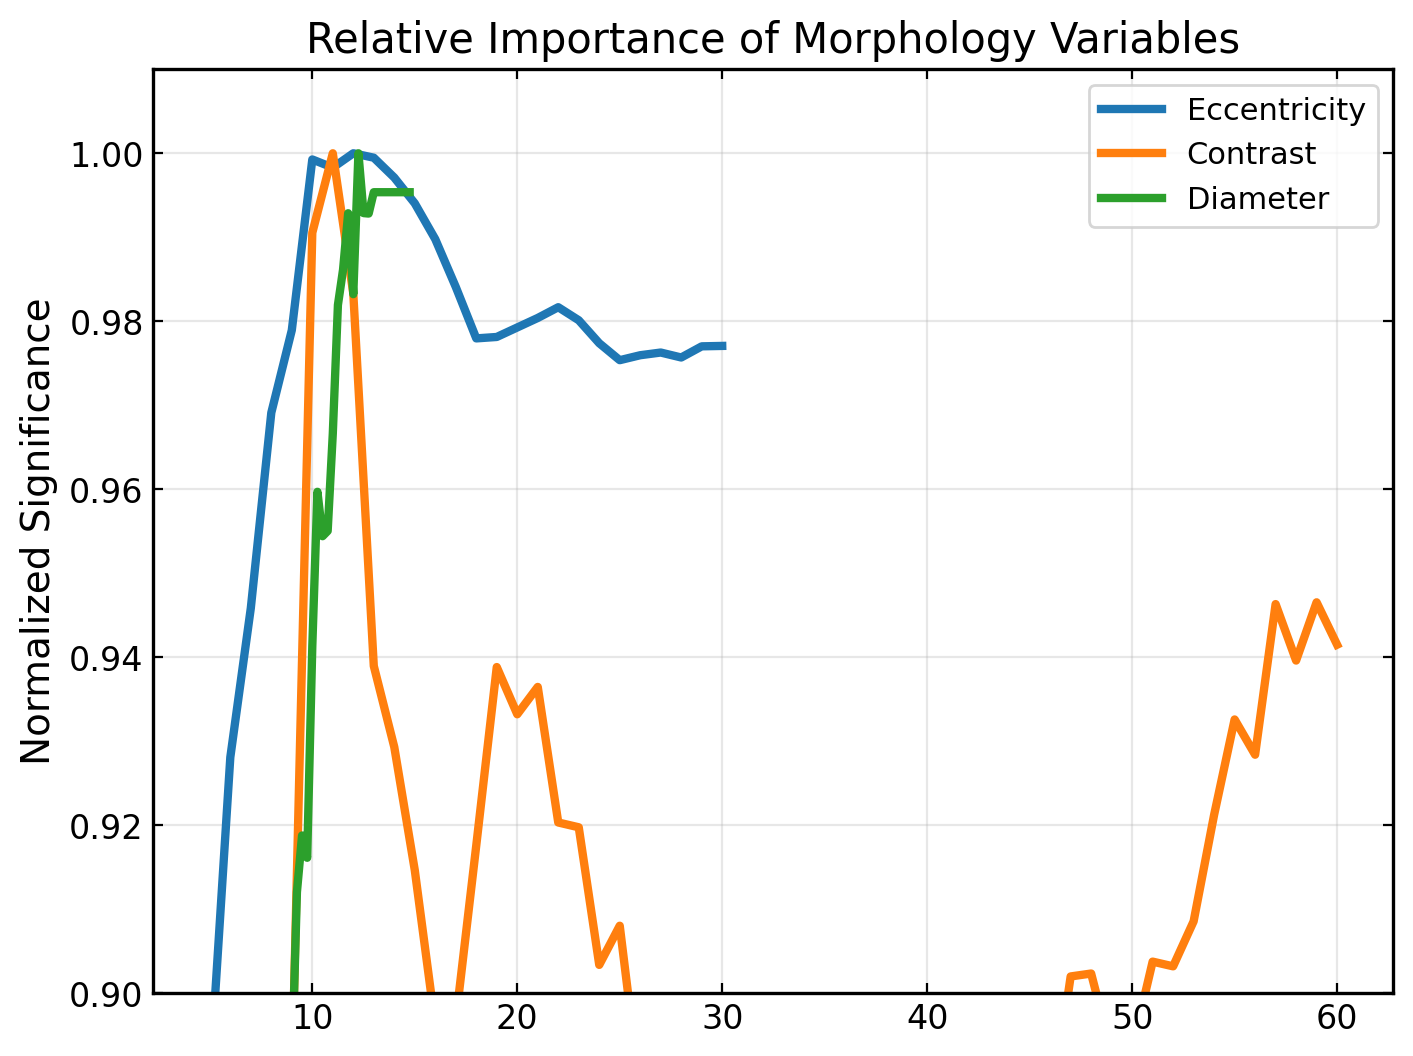

In [38]:
# =============================================================================
# VARIABLE IMPORTANCE SUMMARY
# =============================================================================

fig, ax = plt.subplots(figsize=(8,6))

# Normalize all curves

ecc_norm = ecc_scan.Z / ecc_scan.Z.max()

contrast_norm = contrast_scan.Z / contrast_scan.Z.max()

diam_norm = diameter_scan.Z / diameter_scan.Z.max()

# ----------------------------------------------------

ax.plot(

    ecc_scan.e,

    ecc_norm,

    lw=3,

    label="Eccentricity"

)

ax.plot(

    contrast_scan.c,

    contrast_norm,

    lw=3,

    label="Contrast"

)

ax.plot(

    diameter_scan.dmax,

    diam_norm,

    lw=3,

    label="Diameter"

)

ax.set_ylim(0.90,1.01)

ax.grid(alpha=.3)

ax.legend()

ax.set_ylabel("Normalized Significance")

ax.set_title("Relative Importance of Morphology Variables")

savefig("variable_importance_summary.png")

plt.show()

,d,e,c,theta_inc_deg
d,1.000000,-0.142829,-0.502964,-0.030055
e,-0.142829,1.000000,0.062515,0.023879
c,-0.502964,0.062515,1.000000,0.041627
theta_inc_deg,-0.030055,0.023879,0.041627,1.000000


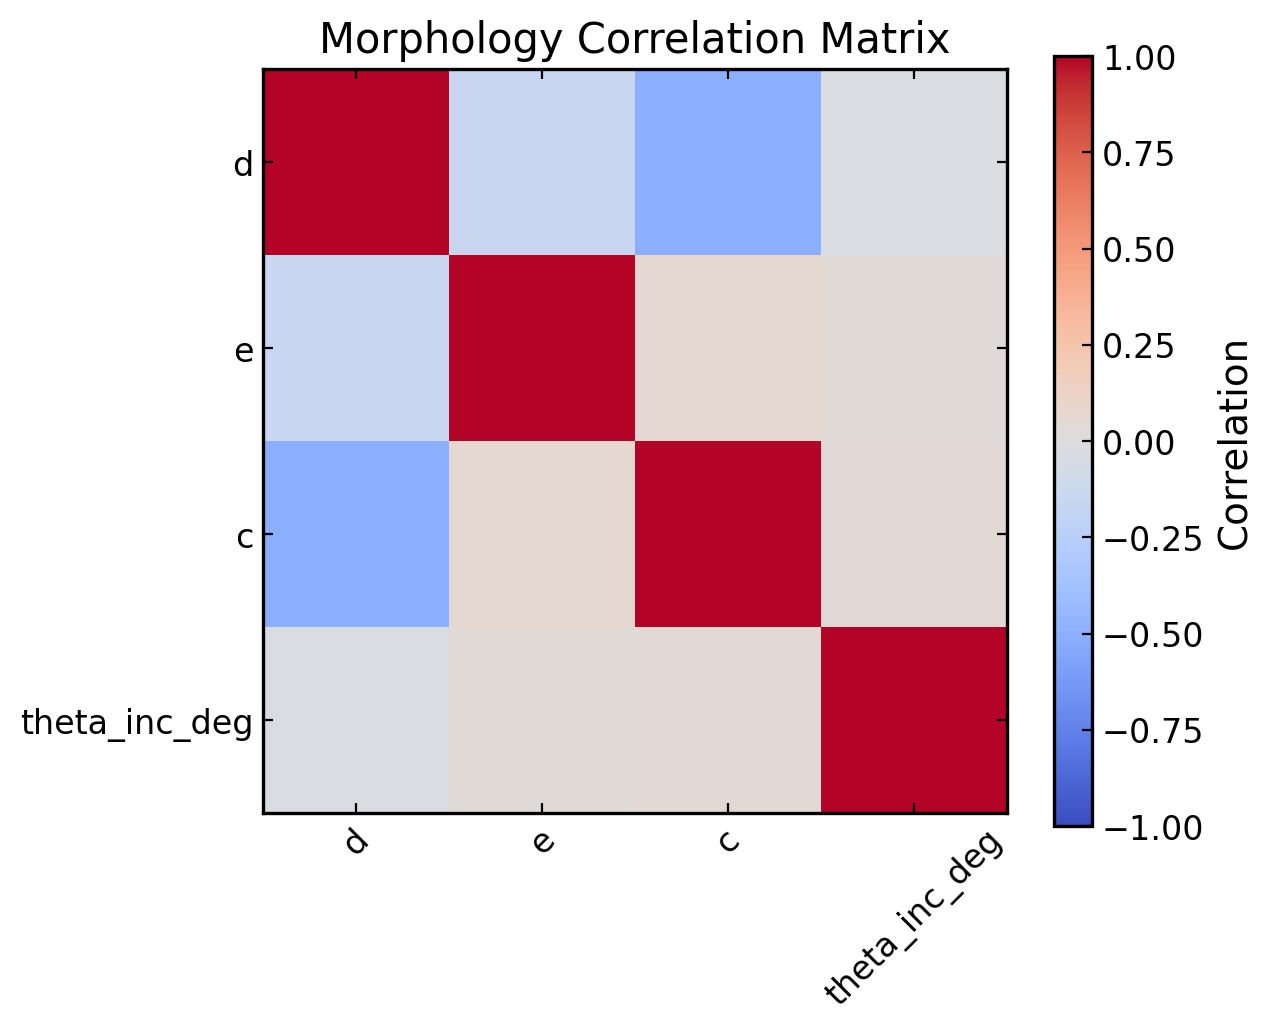

In [39]:
# =============================================================================
# CORRELATION MATRIX
# =============================================================================

corr = tracks[

    [

        "d",

        "e",

        "c",

        "theta_inc_deg"

    ]

].corr()

display(corr)

plt.figure(figsize=(6,5))

plt.imshow(

    corr,

    vmin=-1,

    vmax=1,

    cmap="coolwarm"

)

plt.xticks(

    range(len(corr.columns)),

    corr.columns,

    rotation=45

)

plt.yticks(

    range(len(corr.columns)),

    corr.columns

)

plt.colorbar(label="Correlation")

plt.title("Morphology Correlation Matrix")

savefig("correlation_matrix.png")

plt.show()

In [40]:
# =============================================================================
# FINAL MORPHOLOGY CUTS
# =============================================================================

ECC_FINAL = 20
CONTRAST_FINAL = 19
DIAMETER_MAX_FINAL = 13

tracks["pass_final"]=(

    (tracks.d>=D_MIN)&
    (tracks.d<=DIAMETER_MAX_FINAL)&

    (tracks.e<=ECC_FINAL)&

    (tracks.c<=CONTRAST_FINAL)

)

final_tracks = tracks.loc[
    tracks.pass_final
].copy()

print("="*70)

print("FINAL MORPHOLOGY")

print("="*70)

print(f"Tracks kept : {len(final_tracks):,}")

print(f"Fraction    : {100*len(final_tracks)/len(tracks):.2f}%")

FINAL MORPHOLOGY
Tracks kept : 124,835
Fraction    : 38.29%


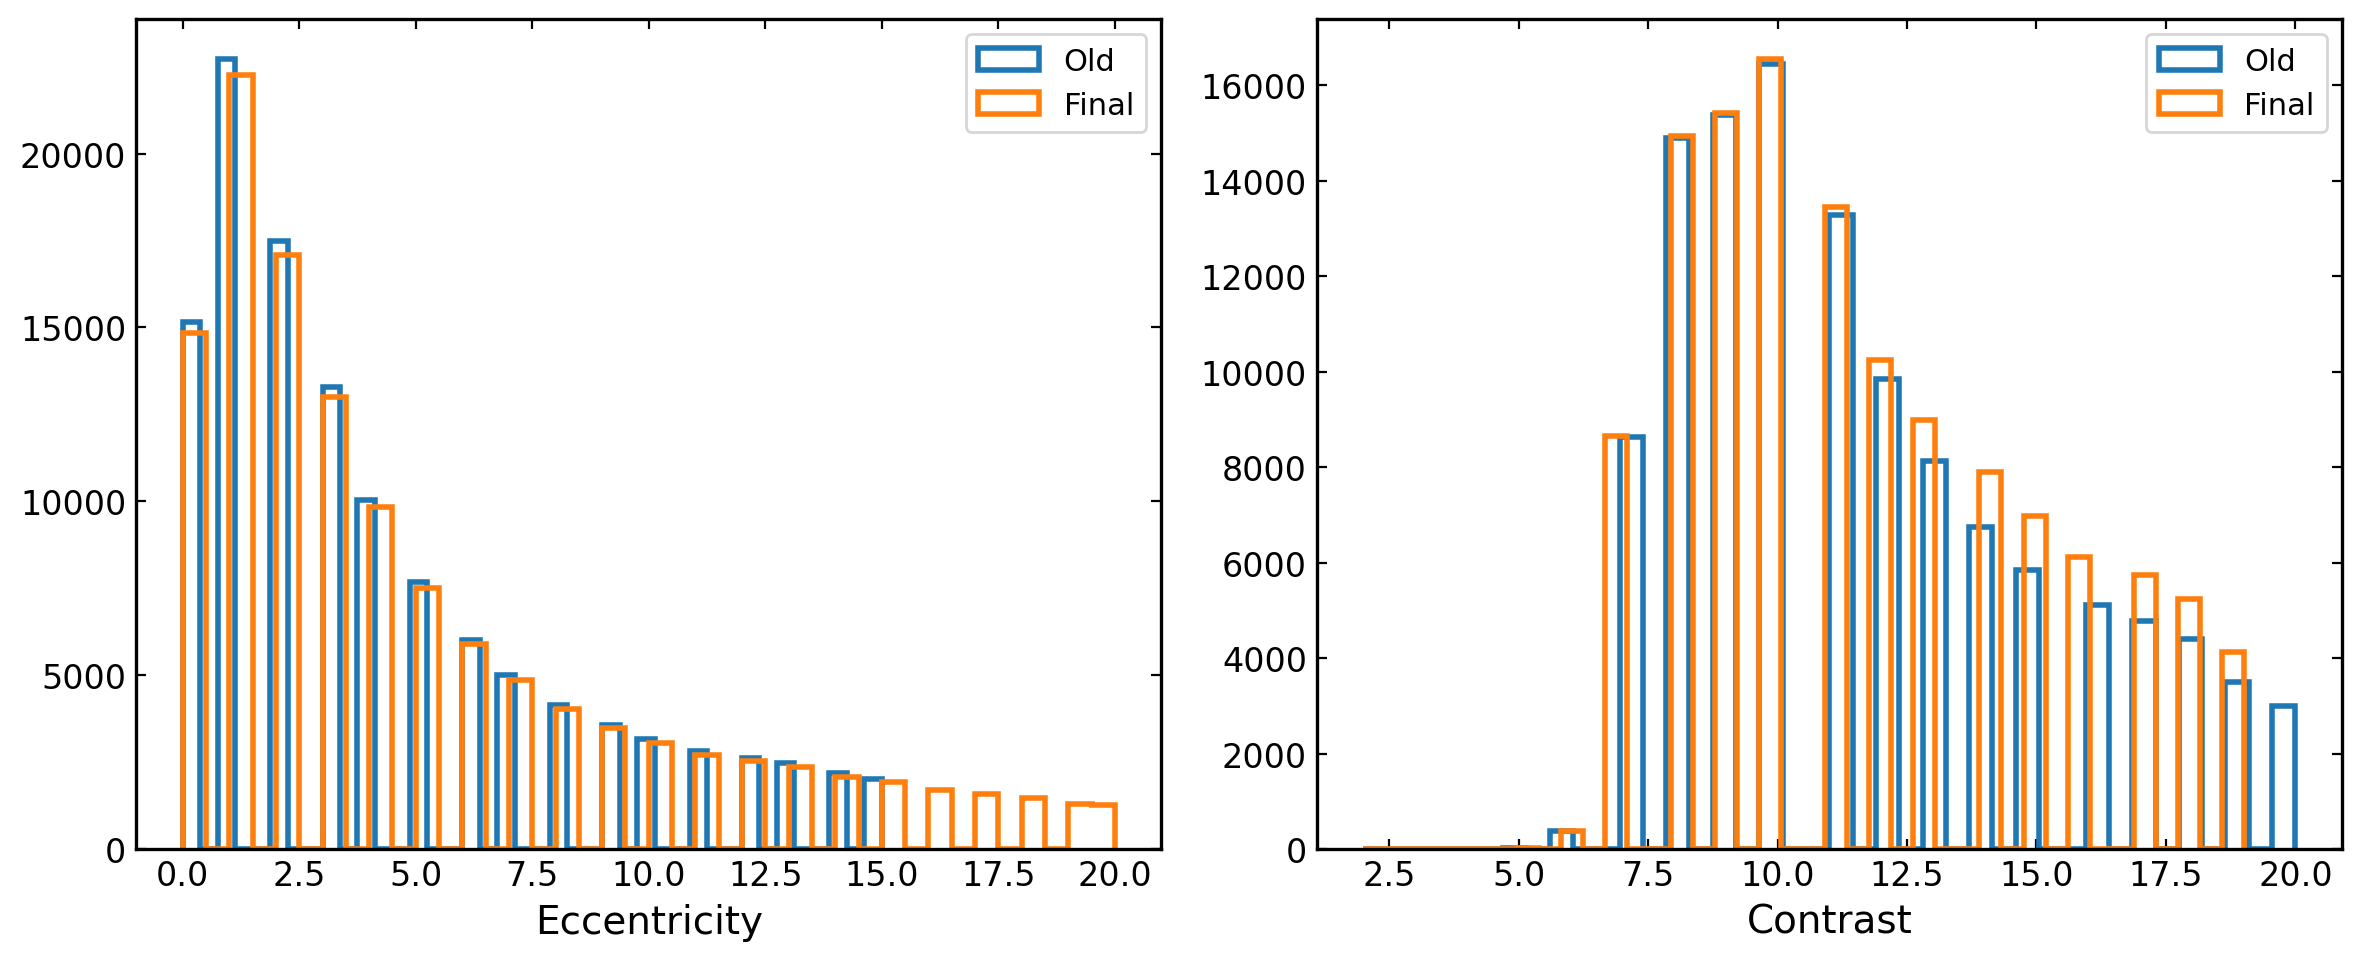

In [41]:
# =============================================================================
# OLD vs FINAL
# =============================================================================

old = tracks.loc[
    tracks.pass_old
]

fig,axs=plt.subplots(

    1,

    2,

    figsize=(12,5)

)

axs[0].hist(

    old.e,

    bins=40,

    histtype="step",

    lw=2,

    label="Old"

)

axs[0].hist(

    final_tracks.e,

    bins=40,

    histtype="step",

    lw=2,

    label="Final"

)

axs[0].legend()

axs[0].set_xlabel("Eccentricity")

# -------------------------------------------------

axs[1].hist(

    old.c,

    bins=40,

    histtype="step",

    lw=2,

    label="Old"

)

axs[1].hist(

    final_tracks.c,

    bins=40,

    histtype="step",

    lw=2,

    label="Final"

)

axs[1].legend()

axs[1].set_xlabel("Contrast")

plt.tight_layout()

savefig("final_morphology.png")

plt.show()

In [42]:
# =============================================================================
# FINAL SIGNAL/BACKGROUND
# =============================================================================

signal_final = final_tracks.loc[

    (final_tracks.r_cm <= SIG_R_MAX)

]

background_final = final_tracks.loc[

    (final_tracks.r_cm > BG_R_MIN) & (final_tracks.r_cm <= BG_R_MAX)

]

Ns = len(signal_final)

Nb = len(background_final)

B = alpha_bg * Nb

Net = Ns - B

sigma = np.sqrt(

    Ns +

    alpha_bg**2 * Nb

)

Z = Net/sigma

print("="*70)

print("FINAL YIELD")

print("="*70)

print(f"Signal              : {Ns}")

print(f"Background          : {Nb}")

print(f"Scaled Background   : {B:.2f}")

print(f"Net                 : {Net:.2f}")

print(f"σ                   : {sigma:.2f}")

print(f"Significance        : {Z:.2f}")

FINAL YIELD
Signal              : 54980
Background          : 39233
Scaled Background   : 50442.43
Net                 : 4537.57
σ                   : 346.17
Significance        : 13.11


In [43]:
# =============================================================================
# ANALYSIS SUMMARY TABLE
# =============================================================================

summary = pd.DataFrame({

"Quantity":[

"Raw Tracks",

"Accepted Tracks",

"Signal",

"Background",

"Scaled Background",

"Net Yield",

"Statistical Error",

"Significance"

],

"Value":[

len(tracks),

len(final_tracks),

Ns,

Nb,

round(B,2),

round(Net,2),

round(sigma,2),

round(Z,2)

]

})

display(summary)

summary.to_csv(

    "analysis_summary.csv",

    index=False

)

,Quantity,Value
0,Raw Tracks,326046.00
1,Accepted Tracks,124835.00
2,Signal,54980.00
3,Background,39233.00
4,Scaled Background,50442.43
5,Net Yield,4537.57
6,Statistical Error,346.17
7,Significance,13.11


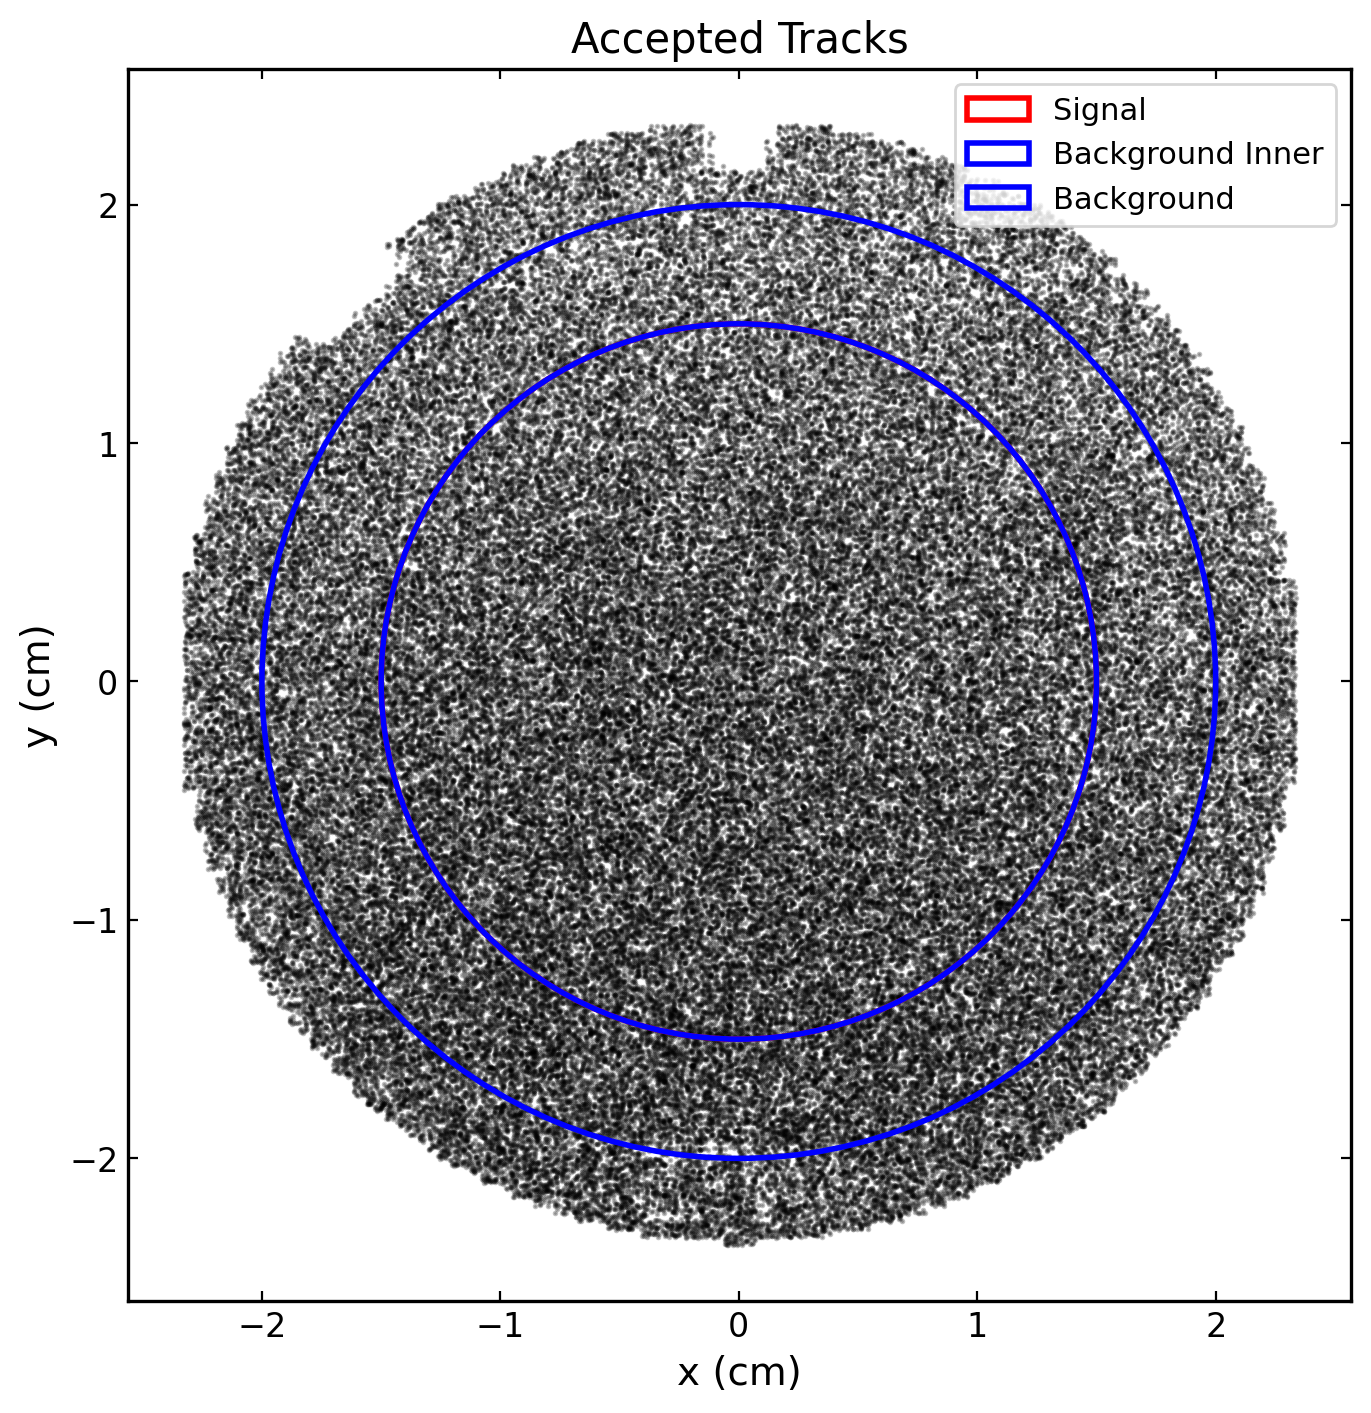

In [44]:
# =============================================================================
# ACCEPTED TRACK MAP
# =============================================================================

fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(
    final_tracks.x,
    final_tracks.y,
    s=1,
    alpha=0.25,
    color="black"
)

signal_rect = patches.Circle(
    (0,0),
    SIG_R_MAX,
    fill=False,
    edgecolor="red",
    lw=2,
    label="Signal"
)

background_rect_inner = patches.Circle(
    (0,0),
    BG_R_MIN,
    fill=False,
    edgecolor="blue",
    lw=2,
    label="Background Inner"
)
background_rect_outer = patches.Circle(
    (0,0),
    BG_R_MAX,
    fill=False,
    edgecolor="blue",
    lw=2,
    label="Background"
)

ax.add_patch(signal_rect)
ax.add_patch(background_rect_inner)
ax.add_patch(background_rect_outer)

ax.set_aspect("equal")

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
ax.set_title("Accepted Tracks")

ax.legend()

savefig("accepted_tracks_map.png")

plt.show()

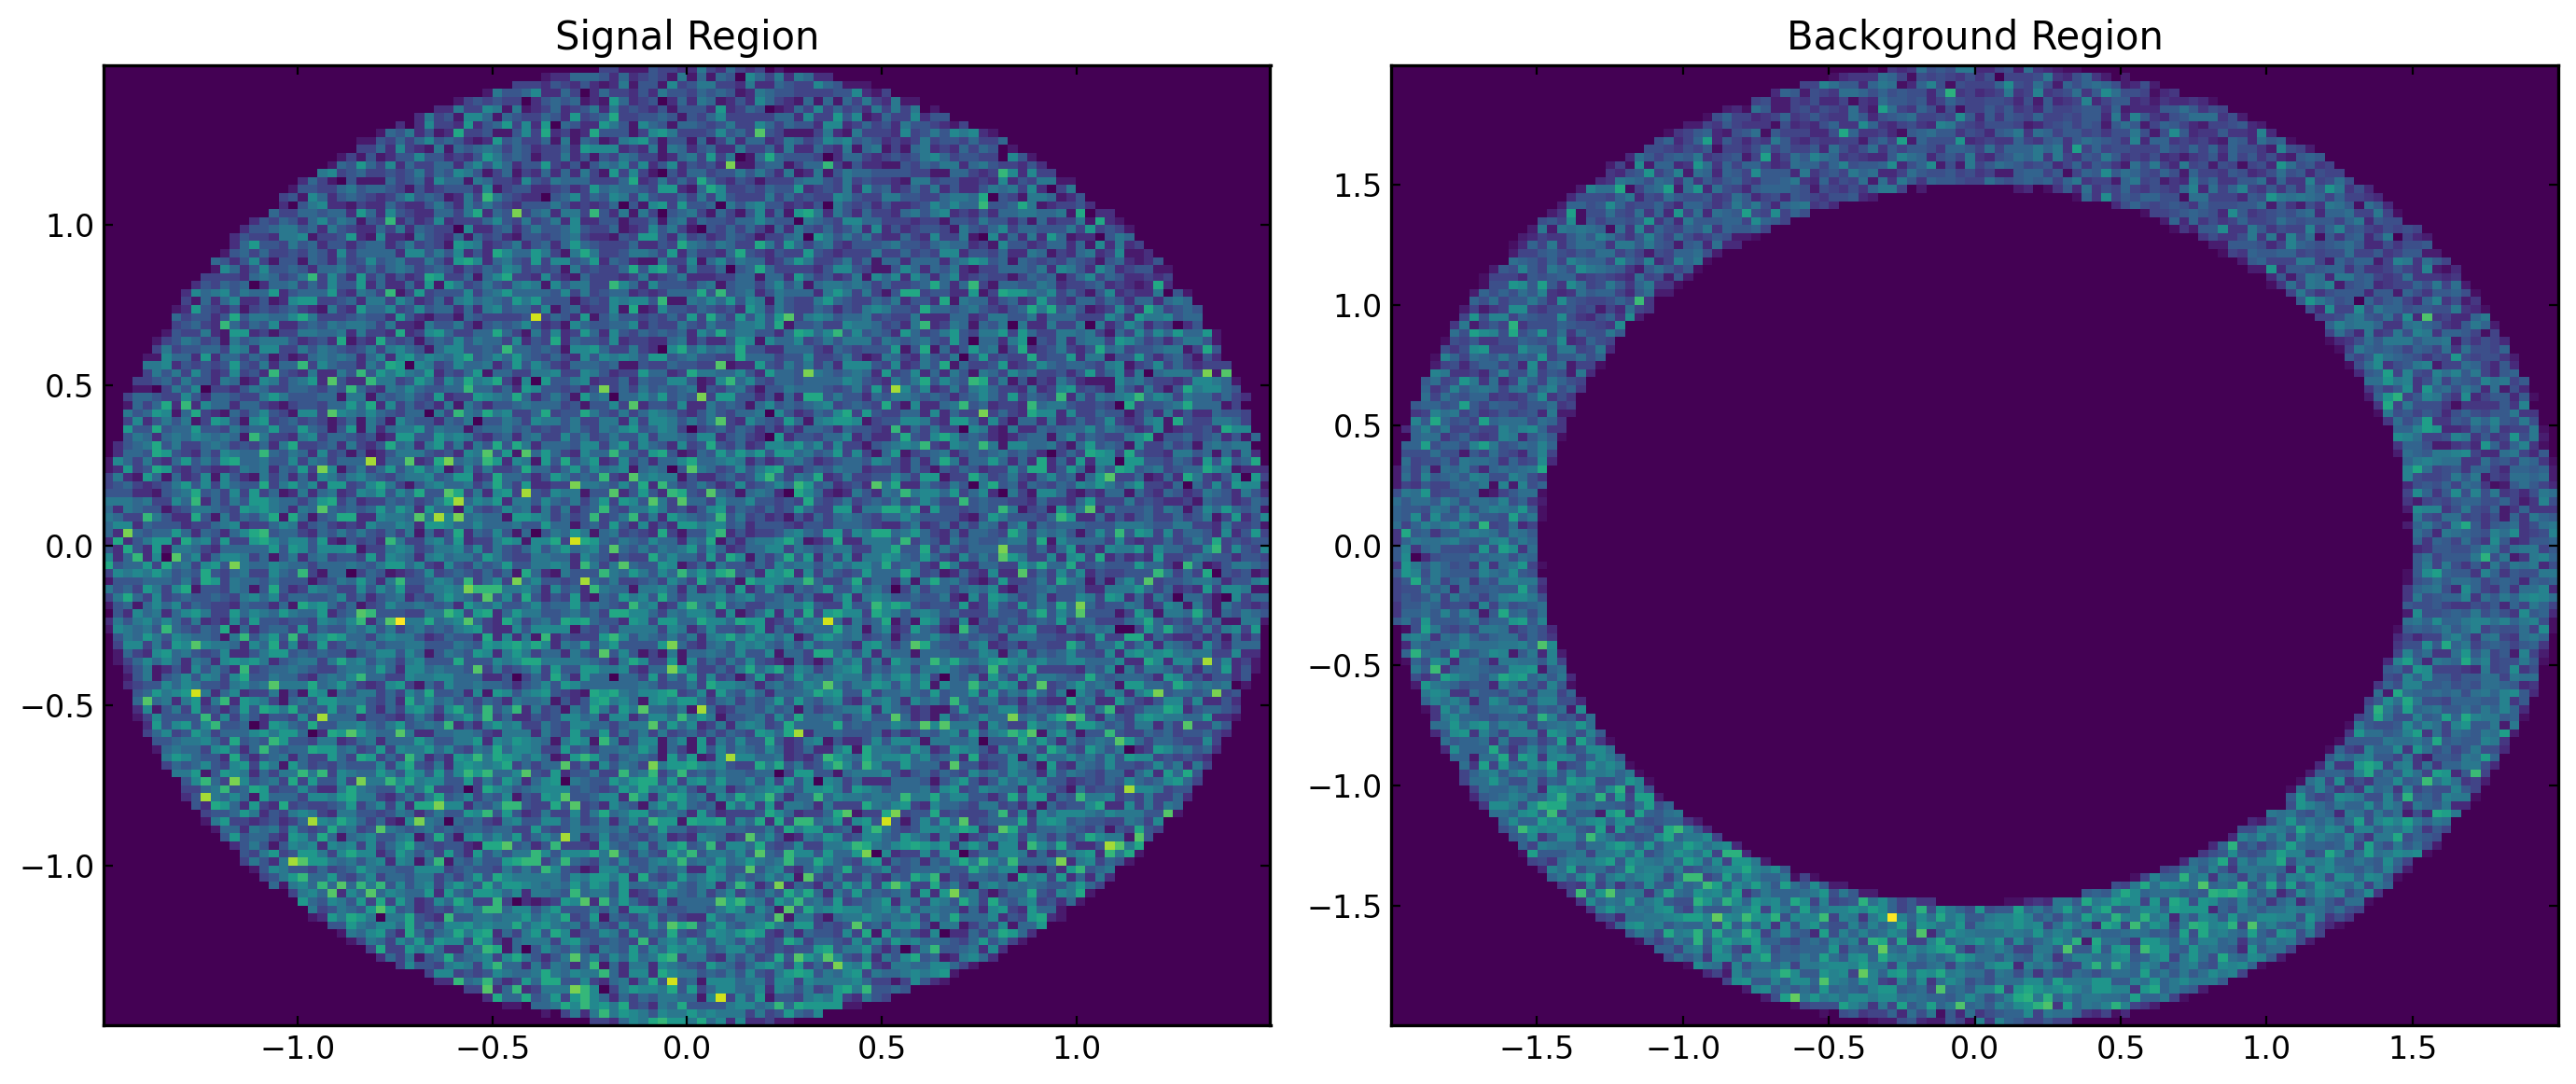

In [45]:
# =============================================================================
# DENSITY MAPS
# =============================================================================

bins = 120

fig, axs = plt.subplots(1,2,figsize=(14,6))

# -----------------------------
# Signal
# -----------------------------

axs[0].hist2d(
    signal_final.x,
    signal_final.y,
    bins=bins,
    cmap="viridis"
)

axs[0].set_title("Signal Region")

# -----------------------------
# Background
# -----------------------------

axs[1].hist2d(
    background_final.x,
    background_final.y,
    bins=bins,
    cmap="viridis"
)

axs[1].set_title("Background Region")

plt.tight_layout()

savefig("density_maps.png")

plt.show()

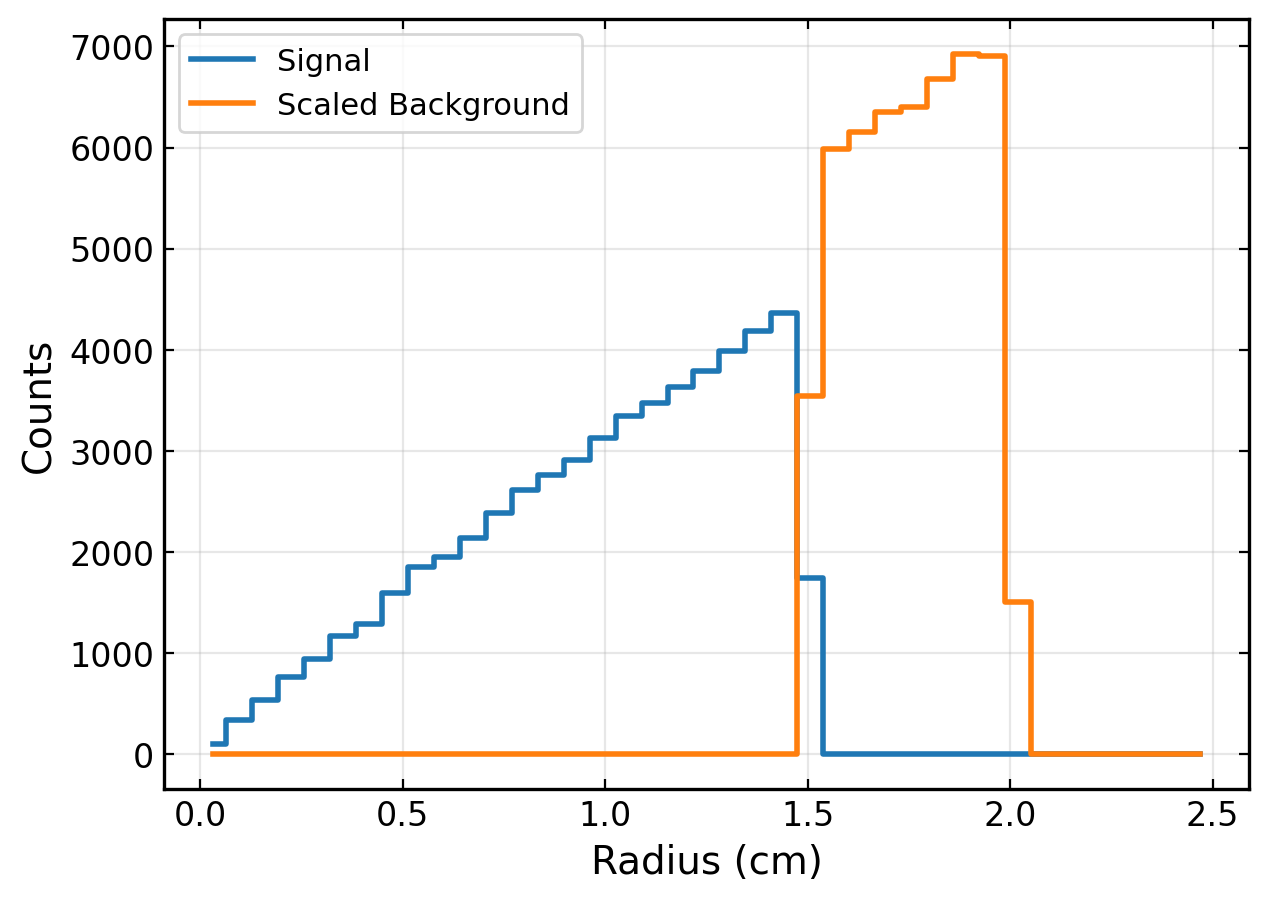

In [46]:
# =============================================================================
# RADIAL PROFILES
# =============================================================================

r_bins = np.linspace(
    0,
    CR39_RADIUS_CM,
    40
)

sig_hist,_ = np.histogram(
    signal_final.r_cm,
    bins=r_bins
)

bg_hist,_ = np.histogram(
    background_final.r_cm,
    bins=r_bins
)

bg_scaled = alpha_bg * bg_hist

centers = 0.5*(r_bins[1:]+r_bins[:-1])

plt.figure(figsize=(7,5))

plt.step(
    centers,
    sig_hist,
    where="mid",
    label="Signal"
)

plt.step(
    centers,
    bg_scaled,
    where="mid",
    label="Scaled Background"
)

plt.xlabel("Radius (cm)")
plt.ylabel("Counts")

plt.legend()

plt.grid(alpha=.3)

savefig("radial_profiles.png")

plt.show()

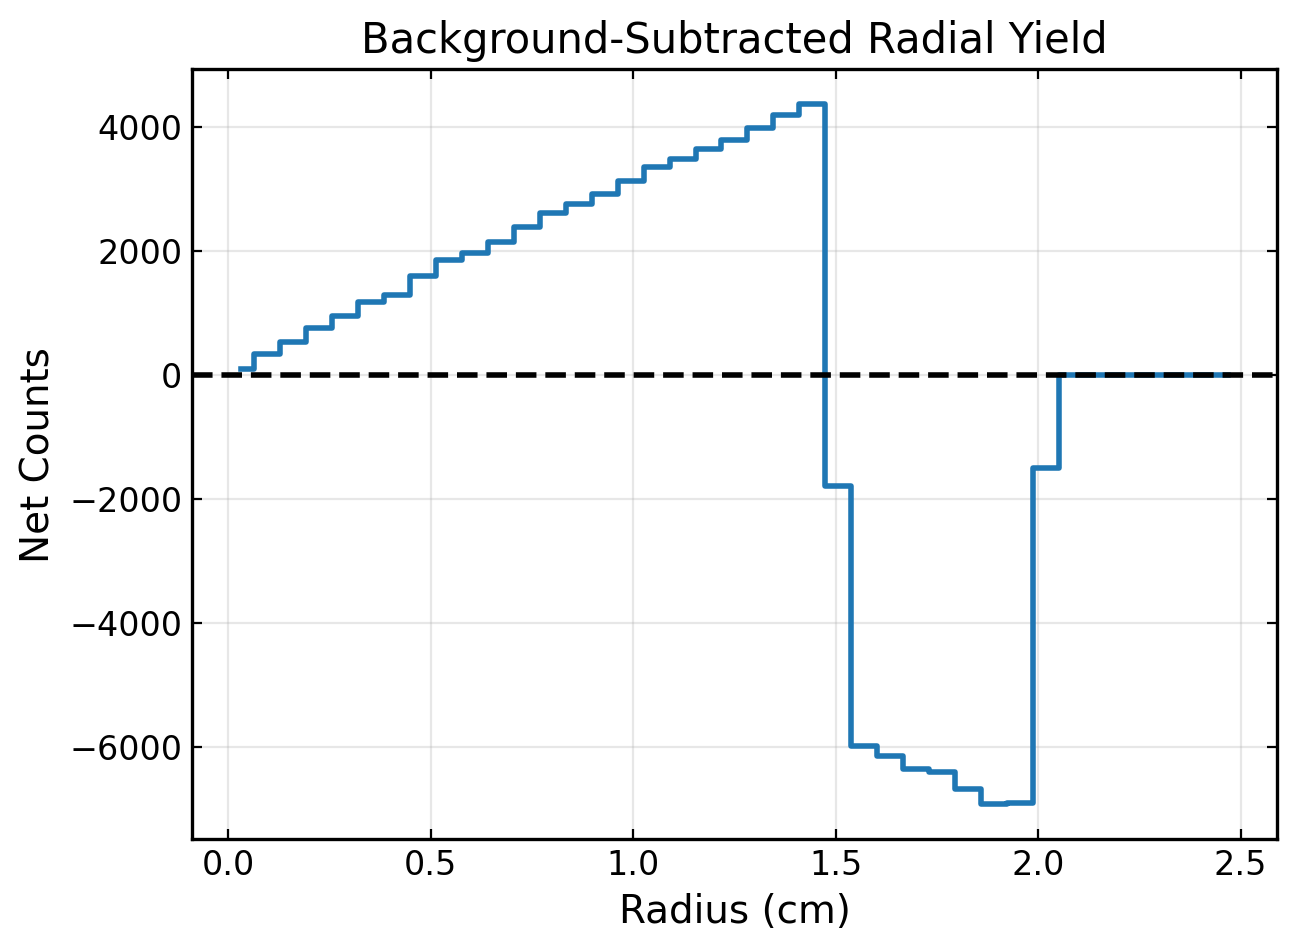

In [47]:
# =============================================================================
# RADIAL RESIDUAL
# =============================================================================

residual = sig_hist - bg_scaled

plt.figure(figsize=(7,5))

plt.step(
    centers,
    residual,
    where="mid",
    lw=2
)

plt.axhline(
    0,
    color="black",
    ls="--"
)

plt.xlabel("Radius (cm)")
plt.ylabel("Net Counts")

plt.title("Background-Subtracted Radial Yield")

plt.grid(alpha=.3)

savefig("radial_residual.png")

plt.show()

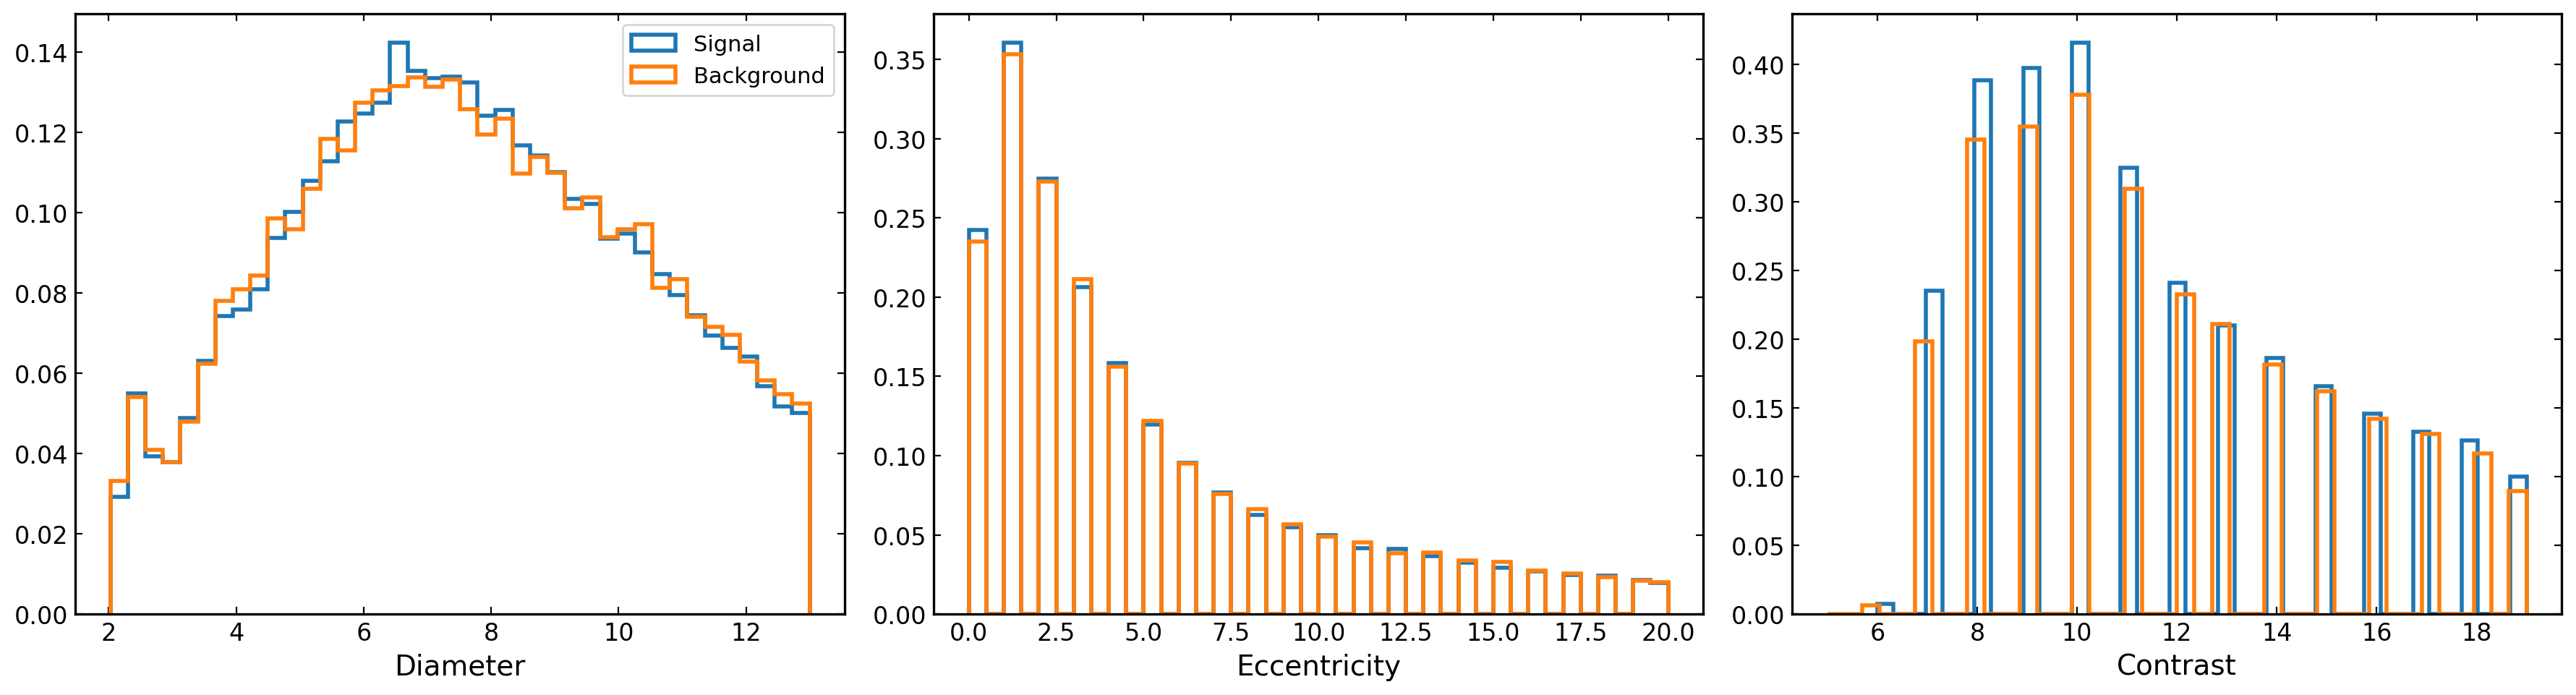

In [48]:
# =============================================================================
# SIGNAL vs BACKGROUND MORPHOLOGY
# =============================================================================

fig, axs = plt.subplots(1,3,figsize=(18,5))

# Diameter
axs[0].hist(
    signal_final.d,
    bins=40,
    density=True,
    histtype="step",
    lw=2,
    label="Signal"
)

axs[0].hist(
    background_final.d,
    bins=40,
    density=True,
    histtype="step",
    lw=2,
    label="Background"
)

axs[0].set_xlabel("Diameter")
axs[0].legend()

# Eccentricity
axs[1].hist(
    signal_final.e,
    bins=40,
    density=True,
    histtype="step",
    lw=2,
    label="Signal"
)

axs[1].hist(
    background_final.e,
    bins=40,
    density=True,
    histtype="step",
    lw=2,
    label="Background"
)

axs[1].set_xlabel("Eccentricity")

# Contrast
axs[2].hist(
    signal_final.c,
    bins=40,
    density=True,
    histtype="step",
    lw=2,
    label="Signal"
)

axs[2].hist(
    background_final.c,
    bins=40,
    density=True,
    histtype="step",
    lw=2,
    label="Background"
)

axs[2].set_xlabel("Contrast")

plt.tight_layout()

savefig("signal_vs_background_morphology.png")

plt.show()

In [49]:
# =============================================================================
# KS TEST: SIGNAL vs BACKGROUND MORPHOLOGY
# =============================================================================

from scipy.stats import ks_2samp

print("="*70)
print("KOLMOGOROV-SMIRNOV TEST")
print("="*70)

for var, label in zip(
    ["d", "e", "c"],
    ["Diameter", "Eccentricity", "Contrast"]
):

    D, p = ks_2samp(
        signal_final[var],
        background_final[var]
    )

    print(f"{label:15s}  D = {D:.4f}   p = {p:.3e}")

KOLMOGOROV-SMIRNOV TEST
Diameter         D = 0.0064   p = 3.111e-01
Eccentricity     D = 0.0084   p = 7.599e-02
Contrast         D = 0.0207   p = 5.977e-09


In [50]:
# =============================================================================
# BACKGROUND SUBTRACTION SUMMARY
# =============================================================================

summary = pd.DataFrame({

    "Quantity":[
        "Signal Counts",
        "Background Counts",
        "Area Scale",
        "Scaled Background",
        "Net Yield",
        "Statistical Error",
        "Significance"
    ],

    "Value":[
        Ns,
        Nb,
        alpha_bg,
        round(B,2),
        round(Net,2),
        round(sigma,2),
        round(Z,2)
    ]

})

display(summary)

summary.to_csv(
    "background_summary.csv",
    index=False
)

,Quantity,Value
0,Signal Counts,54980.000000
1,Background Counts,39233.000000
2,Area Scale,1.285714
3,Scaled Background,50442.430000
4,Net Yield,4537.570000
5,Statistical Error,346.170000
6,Significance,13.110000


In [51]:
import numpy as np

# --------------------------------------------------
# Signal-region dimensions
# --------------------------------------------------

width = SIG_R_MAX * 2
height = SIG_R_MAX * 2

a = width/2
b = height/2

r = 6.0      # cm (This is the CR39_DISTANCE_CM from before)

# --------------------------------------------------
# Exact rectangular solid angle
# --------------------------------------------------

Omega = 4*np.arctan(
    (a*b) /
    (r*np.sqrt(r**2 + a**2 + b**2))
)

print(f"Signal area = {width*height:.3f} cm²")
print(f"Solid angle = {Omega:.5f} sr")
print(f"Fraction of 4π = {Omega/(4*np.pi):.5f}")

Signal area = 9.000 cm²
Solid angle = 0.23543 sr
Fraction of 4π = 0.01873


In [52]:
acceptance = Omega/(4*np.pi)

print(f"Acceptance = {acceptance:.5%}")

Acceptance = 1.87349%


In [53]:
# =============================================================================
# CROSS-SECTION CALCULATION (PENDING NORMALIZATION)
# =============================================================================

# Background-subtracted CR39 proton yield
N_signal_net = Net

# Placeholders for N_beam and N_target
# User must replace these with actual experimental values
N_beam = 1.0 # Placeholder: replace with actual number of incident deuterons
N_target = 1.0 # Placeholder: replace with actual target areal density (atoms/cm²)

# Calculate differential cross section (dsigma/dOmega)
dsigma = N_signal_net / (N_beam * N_target * Omega)

print("="*70)
print("DIFFERENTIAL CROSS SECTION")
print("="*70)

print(f"Net proton yield : {N_signal_net:.2f}")
print(f"Detector solid angle Ω : {Omega:.6f} sr")
print(f"Differential Cross Section dσ/dΩ : {dsigma:.5e}")

print("\nStill required:")
print("  • N_beam   = Total incident deuterons (replace placeholder)")
print("  • N_target = Target areal density (atoms/cm²) (replace placeholder)")

DIFFERENTIAL CROSS SECTION
Net proton yield : 4537.57
Detector solid angle Ω : 0.235430 sr
Differential Cross Section dσ/dΩ : 1.92735e+04

Still required:
  • N_beam   = Total incident deuterons (replace placeholder)
  • N_target = Target areal density (atoms/cm²) (replace placeholder)


In [54]:
# =============================================================================
# FINAL CR39 YIELD
# =============================================================================

yield_table = pd.DataFrame({

    "Quantity":[
        "Raw Tracks",
        "Accepted Tracks",
        "Selection Efficiency",
        "Signal Counts",
        "Background Counts",
        "Scaled Background",
        "Net Proton Yield",
        "Statistical Uncertainty",
        "Detection Significance"
    ],

    "Value":[
        len(tracks),
        len(final_tracks),
        round(selection_efficiency,4),
        Ns,
        Nb,
        round(B,2),
        round(Net,2),
        round(sigma,2),
        round(Z,2)
    ]

})

display(yield_table)

print("-"*50)

# =============================================================================
# STATISTICAL UNCERTAINTY
# =============================================================================

sigma_signal = np.sqrt(Ns)

sigma_background = alpha_bg * np.sqrt(Nb)

sigma_total = np.sqrt(
    sigma_signal**2 +
    sigma_background**2
)

uncertainty = pd.DataFrame({

    "Source":[
        "Signal Counting",
        "Background Counting",
        "Total"
    ],

    "Absolute":[
        sigma_signal,
        sigma_background,
        sigma_total
    ],

    "Relative (%)":[
        100*sigma_signal/Net,
        100*sigma_background/Net,
        100*sigma_total/Net
    ]

})

display(uncertainty)



NameError: name 'selection_efficiency' is not defined

In [ ]:
# =============================================================================
# FINAL CR39 REPORT
# =============================================================================

print("="*75)
print("             CR39 FINAL ANALYSIS")
print("="*75)

print(f"Raw Tracks                  : {len(tracks):,}")
print(f"Accepted Tracks             : {len(final_tracks):,}")
print(f"Selection Efficiency        : {100*selection_efficiency:.2f}%")

print()

print(f"Signal Counts               : {Ns}")
print(f"Background Counts           : {Nb}")
print(f"Scaled Background           : {B:.2f}")

print()

print(f"Net Proton Yield            : {Net:.2f}")
print(f"Statistical Error           : {sigma_total:.2f}")
print(f"Relative Error              : {100*sigma_total/Net:.2f}%")
print(f"Detection Significance      : {Z:.2f}")

print()

print(f"CR39 Solid Angle            : {omega:.6f} sr")

print("="*75)

In [ ]:
import json
summary = {
    'Ns': float(Ns),
    'Nb': float(Nb),
    'B': float(B),
    'Net': float(Net),
    'sigma_total': float(sigma_total)
}
with open('cr39_summary.json', 'w') as f:
    json.dump(summary, f)
print('Summary saved to cr39_summary.json')
